# Member 3: Evaluation of the AI Financial Analyst Framework

## Overview

The proposed AI Financial Analyst framework consists of two complementary components:

1. **Baseline Multi-Layer Perceptron (MLP) Model**
   - Developed in Member 1's notebook.
   - Performs structured financial prediction by classifying companies into **Buy**, **Hold**, and **Sell** categories using financial indicators.
   - Serves as the predictive baseline for the overall system.

2. **Retrieval-Augmented Generation (RAG) Framework**
   - Developed in Member 2's notebook.
   - Generates detailed financial reports using external financial knowledge retrieved from the EDGAR corpus.

This notebook focuses on evaluating the **RAG report generation framework**, while referencing the predictive performance of the MLP model to provide a complete evaluation of the proposed AI Financial Analyst system.

In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [3]:
# =============================================================================
# STEP 2: CONFIGURE NOTEBOOK DISPLAY SETTINGS
# =============================================================================
#
# Pandas hides columns when datasets contain many variables.
# Since our financial dataset contains more than 200 columns,
# we display all columns to simplify inspection.
# =============================================================================

# Display all columns
pd.set_option("display.max_columns", None)

# Display up to 100 rows
pd.set_option("display.max_rows", 100)

# Display complete text inside each cell
pd.set_option("display.max_colwidth", None)

In [4]:
# =============================================================================
# STEP 3: DEFINE PROJECT DIRECTORY
# =============================================================================
#
# The notebook is stored inside:
#
# notebooks/
#
# The datasets are stored inside:
#
# data/processed/
#
# Therefore we move one directory upward using ".."
# and then navigate into data/processed.
# =============================================================================

# Project root directory
PROJECT_ROOT = Path("..")

# Processed data directory
DATA_PATH = PROJECT_ROOT / "data" / "processed"

# Display the resolved path for verification
print("Processed Data Folder:")
print(DATA_PATH.resolve())

Processed Data Folder:
C:\Rakhi's Workplace\NCI\MODULES - SEM 2\2. Deep Learning and Generative AI\AI_Financial_Analyst\data\processed


In [5]:
# =============================================================================
# STEP 4: VERIFY REQUIRED PROJECT FILES
# =============================================================================
#
# Before loading datasets, check whether each required file exists.
# This prevents confusing FileNotFoundError exceptions later.
# =============================================================================

required_files = [
    "processed_financial_data.csv",
    "company_mapping.csv",
    "selected_companies.csv",
    "generated_reports_final.csv"
]

for file in required_files:
    file_path = DATA_PATH / file

    if file_path.exists():
        print(f"✔ {file}")
    else:
        print(f"✘ {file} NOT FOUND")

✔ processed_financial_data.csv
✔ company_mapping.csv
✔ selected_companies.csv
✔ generated_reports_final.csv


In [6]:
# =============================================================================
# STEP 5: VERIFY REQUIRED PROJECT FILES
# =============================================================================
#
# Before loading datasets, check whether each required file exists.
# This prevents confusing FileNotFoundError exceptions later.
# =============================================================================

required_files = [
    "processed_financial_data.csv",
    "company_mapping.csv",
    "selected_companies.csv",
    "generated_reports_final.csv"
]

for file in required_files:
    file_path = DATA_PATH / file

    if file_path.exists():
        print(f"✔ {file}")
    else:
        print(f"✘ {file} NOT FOUND")

✔ processed_financial_data.csv
✔ company_mapping.csv
✔ selected_companies.csv
✔ generated_reports_final.csv


In [7]:
# =============================================================================
# STEP 6: LOAD PROJECT DATASETS
# =============================================================================
#
# Four datasets are required for Member 3's evaluation:
#
# 1. processed_financial_data.csv
#       Structured financial indicators prepared by Member 1
#
# 2. company_mapping.csv
#       Maps company names, tickers, sectors and CIK identifiers
#
# 3. selected_companies.csv
#       Contains the companies selected for experimentation
#
# 4. generated_reports_final.csv
#       Contains financial reports generated by the RAG + LLM pipeline
#
# These datasets form the basis for all subsequent evaluation tasks.
# =============================================================================

processed_df = pd.read_csv(DATA_PATH / "processed_financial_data.csv")

mapping_df = pd.read_csv(DATA_PATH / "company_mapping.csv")

companies_df = pd.read_csv(DATA_PATH / "selected_companies.csv")

reports_df = pd.read_csv(DATA_PATH / "generated_reports_final.csv")

In [8]:
# =============================================================================
# STEP 7: VERIFY DATASET DIMENSIONS
# =============================================================================
#
# The shape of each dataset is displayed as:
#
# (Number of Rows, Number of Columns)
#
# This confirms that the datasets were loaded successfully.
# =============================================================================

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Processed Financial Data : {processed_df.shape}")

print(f"Company Mapping          : {mapping_df.shape}")

print(f"Selected Companies       : {companies_df.shape}")

print(f"Generated Reports        : {reports_df.shape}")

DATASET SUMMARY
Processed Financial Data : (110, 217)
Company Mapping          : (110, 5)
Selected Companies       : (22, 4)
Generated Reports        : (1312, 16)


=============================================================================
## STEP 8: VERIFY DATASET DIMENSIONS
=============================================================================
Display the dimensions of each dataset.

Dataset shape is represented as:

(Number of Rows, Number of Columns)

This confirms that all required datasets have been loaded correctly

before proceeding with data inspection and preprocessing.

 =============================================================================

In [9]:

print("=" * 70)
print("PROJECT DATASET SUMMARY")
print("=" * 70)

print(f"Processed Financial Data : {processed_df.shape}")
print("   -> Contains structured financial metrics prepared by Member 1.\n")

print(f"Company Mapping          : {mapping_df.shape}")
print("   -> Maps company names, tickers, CIKs and sectors.\n")

print(f"Selected Companies       : {companies_df.shape}")
print("   -> Final list of companies selected for the study.\n")

print(f"Generated Reports        : {reports_df.shape}")
print("   -> LLM-generated financial reports created using the RAG pipeline.")

PROJECT DATASET SUMMARY
Processed Financial Data : (110, 217)
   -> Contains structured financial metrics prepared by Member 1.

Company Mapping          : (110, 5)
   -> Maps company names, tickers, CIKs and sectors.

Selected Companies       : (22, 4)
   -> Final list of companies selected for the study.

Generated Reports        : (1312, 16)
   -> LLM-generated financial reports created using the RAG pipeline.


## Step 9: Initial Data Inspection

The objective of this step is to perform an initial exploration of each dataset before any preprocessing or analysis.

This inspection will help to:

- Understand the structure of each dataset.
- Identify important variables and key identifiers.
- Verify that the datasets have been loaded correctly.
- Prepare for merging the datasets in the subsequent phase.

No modifications to the datasets are performed during this step.

In [10]:
# =============================================================================
# STEP 9.1: INSPECT PROCESSED FINANCIAL DATASET
# =============================================================================
#
# This dataset contains structured financial indicators prepared during the
# data engineering phase (Member 1).
#
# We inspect the first five records to:
#
# • Understand the overall structure
# • Identify important financial variables
# • Verify that the dataset loaded correctly
#
# =============================================================================

print("=" * 70)
print("PROCESSED FINANCIAL DATASET")
print("=" * 70)

processed_df.head()

PROCESSED FINANCIAL DATASET


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,Profit Margin,Free Cash Flow margin,EBITDA,EBIT,Consolidated Income,Earnings Before Tax Margin,Net Profit Margin,Cash and cash equivalents,Short-term investments,Cash and short-term investments,Receivables,Inventories,Total current assets,"Property, Plant & Equipment Net",Goodwill and Intangible Assets,Long-term investments,Tax assets,Total non-current assets,Total assets,Payables,Short-term debt,Total current liabilities,Long-term debt,Total debt,Deferred revenue,Tax Liabilities,Deposit Liabilities,Total non-current liabilities,Total liabilities,Other comprehensive income,Retained earnings (deficit),Total shareholders equity,Investments,Net Debt,Other Assets,Other Liabilities,Depreciation & Amortization,Stock-based compensation,Operating Cash Flow,Capital Expenditure,Acquisitions and disposals,Investment purchases and sales,Investing Cash flow,Issuance (repayment) of debt,Issuance (buybacks) of shares,Dividend payments,Financing Cash Flow,Effect of forex changes on cash,Net cash flow / Change in cash,Free Cash Flow,Net Cash/Marketcap,priceBookValueRatio,priceToBookRatio,priceToSalesRatio,priceEarningsRatio,priceToFreeCashFlowsRatio,priceToOperatingCashFlowsRatio,priceCashFlowRatio,priceSalesRatio,dividendYield,enterpriseValueMultiple,priceFairValue,ebitperRevenue,ebtperEBIT,niperEBT,grossProfitMargin,operatingProfitMargin,pretaxProfitMargin,netProfitMargin,effectiveTaxRate,returnOnAssets,returnOnEquity,returnOnCapitalEmployed,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,daysOfInventoryOutstanding,daysOfPayablesOutstanding,debtRatio,debtEquityRatio,longtermDebtToCapitalization,totalDebtToCapitalization,interestCoverage,cashFlowToDebtRatio,companyEquityMultiplier,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,payoutRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,cashFlowCoverageRatios,capitalExpenditureCoverageRatios,dividendpaidAndCapexCoverageRatios,Revenue per Share,Net Income per Share,Operating Cash Flow per Share,Free Cash Flow per Share,Cash per Share,Book Value per Share,Tangible Book Value per Share,Shareholders Equity per Share,Interest Debt per Share,Market Cap,Enterprise Value,PE ratio,Price to Sales Ratio,POCF ratio,PFCF ratio,PB ratio,PTB ratio,EV to Sales,Enterprise Value over EBITDA,EV to Operating cash flow,EV to Free cash flow,Earnings Yield,Free Cash Flow Yield,Debt to Equity,Debt to Assets,Net Debt to EBITDA,Current ratio,Interest Coverage,Income Quality,Dividend Yield,Payout Ratio,SG&A to Revenue,R&D to Revenue,Intangibles to Total Assets,Capex to Operating Cash Flow,Capex to Revenue,Capex to Depreciation,Stock-based compensation to Revenue,Graham Number,ROIC,Return on Tangible Assets,Graham Net-Net,Working Capital,Tangible Asset Value,Net Current Asset Value,Invested Capital,Average Receivables,Average Payables,Average Inventory,Days Sales Outstanding,Days Payables Outstanding,Days of Inventory on Hand,Receivables Turnover,Payables Turnover,Inventory Turnover,ROE,Capex per Share,Gross Profit Growth,EBIT Growth,Operating Income Growth,Net Income Growth,EPS Growth,EPS Diluted Growth,Weighted Average Shares Growth,Weighted Average Shares Diluted Growth,Dividends per Share Growth,Operating Cash Flow growth,Free Cash Flow growth,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growt

In [11]:
# =============================================================================
# DISPLAY BASIC INFORMATION
# =============================================================================
#
# The info() function provides:
# • Number of rows
# • Number of columns
# • Column names
# • Data types
# • Missing values
#
# This helps assess the overall quality of the dataset.
# =============================================================================

processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Columns: 217 entries, ticker to 2019 PRICE VAR [%]
dtypes: float64(213), int64(2), object(2)
memory usage: 186.6+ KB


In [12]:
processed_df.columns.tolist()

['ticker',
 'Revenue',
 'Revenue Growth',
 'Cost of Revenue',
 'Gross Profit',
 'R&D Expenses',
 'SG&A Expense',
 'Operating Expenses',
 'Operating Income',
 'Interest Expense',
 'Earnings before Tax',
 'Income Tax Expense',
 'Net Income - Non-Controlling int',
 'Net Income - Discontinued ops',
 'Net Income',
 'Preferred Dividends',
 'Net Income Com',
 'EPS',
 'EPS Diluted',
 'Weighted Average Shs Out',
 'Weighted Average Shs Out (Dil)',
 'Dividend per Share',
 'Gross Margin',
 'EBITDA Margin',
 'EBIT Margin',
 'Profit Margin',
 'Free Cash Flow margin',
 'EBITDA',
 'EBIT',
 'Consolidated Income',
 'Earnings Before Tax Margin',
 'Net Profit Margin',
 'Cash and cash equivalents',
 'Short-term investments',
 'Cash and short-term investments',
 'Receivables',
 'Inventories',
 'Total current assets',
 'Property, Plant & Equipment Net',
 'Goodwill and Intangible Assets',
 'Long-term investments',
 'Tax assets',
 'Total non-current assets',
 'Total assets',
 'Payables',
 'Short-term debt',
 '

In [13]:
# =============================================================================
# DESCRIPTIVE STATISTICS
# =============================================================================
#
# Generate summary statistics for all numerical variables.
#
# This provides an overview of:
# • Mean
# • Standard deviation
# • Minimum and maximum values
# • Quartiles
#
# These statistics help understand the distribution of financial metrics.
# =============================================================================

processed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Revenue,110.0,1.011071e+10,3.284950e+10,3.541000e+06,7.422775e+07,3.604950e+08,1.994100e+09,1.707560e+11
Revenue Growth,110.0,1.177000e-01,3.783117e-01,-6.418000e-01,-1.965000e-02,6.080000e-02,1.469250e-01,2.854300e+00
Cost of Revenue,110.0,5.025716e+09,1.536281e+10,0.000000e+00,2.158675e+07,1.693060e+08,1.483325e+09,7.941900e+10
Gross Profit,110.0,5.084995e+09,1.755672e+10,-2.068300e+07,2.039900e+07,1.404110e+08,1.177100e+09,9.133700e+10
R&D Expenses,110.0,1.158226e+07,2.469243e+07,0.000000e+00,0.000000e+00,0.000000e+00,5.226750e+06,1.043810e+08
...,...,...,...,...,...,...,...,...
year,110.0,2.016000e+03,1.420686e+00,2.014000e+03,2.015000e+03,2.016000e+03,2.017000e+03,2.018000e+03
2016 PRICE VAR [%],22.0,9.250247e+00,3.872881e+01,-7.638426e+01,-1.786446e+01,1.204875e+01,4.304818e+01,6.035295e+01
2017 PRICE VAR [%],22.0,1.937653e+01,4.006449e+01,-4.796134e+01,-4.654185e+00,1.547722e+01,3.122958e+01,1.320186e+02
2018 PRICE VAR [%],22.0,-1.549863e+01,2.526746e+01,-9.315068e+01,-2.757183e+01,-8.351166e+00,-6.894899e-01,2.475248e+01


In [14]:
# =============================================================================
# CHECK FOR MISSING VALUES
# =============================================================================
#
# Missing values may affect later analysis and dataset merging.
#
# Here we count the number of missing values in each column.
# Only columns containing missing values are displayed.
# =============================================================================

missing_values = processed_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

2015 PRICE VAR [%]    88
2016 PRICE VAR [%]    88
2017 PRICE VAR [%]    88
2018 PRICE VAR [%]    88
2019 PRICE VAR [%]    88
dtype: int64

In [15]:
# =============================================================================
# STEP 9.1.4: CHECK FOR DUPLICATE RECORDS
# =============================================================================
#
# Duplicate records may affect analysis and dataset merging.
#
# This step counts the number of duplicated rows.
# =============================================================================

duplicates = processed_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [16]:
# =============================================================================
# STEP 9.1.5: SUMMARY STATISTICS
# =============================================================================
#
# Generate descriptive statistics for all numerical variables.
#
# This provides:
#   • Mean
#   • Standard deviation
#   • Minimum
#   • Maximum
#   • Quartiles
#
# The transpose (.T) makes the output easier to read.
# =============================================================================

processed_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Revenue,110.0,1.011071e+10,3.284950e+10,3.541000e+06,7.422775e+07,3.604950e+08,1.994100e+09,1.707560e+11
Revenue Growth,110.0,1.177000e-01,3.783117e-01,-6.418000e-01,-1.965000e-02,6.080000e-02,1.469250e-01,2.854300e+00
Cost of Revenue,110.0,5.025716e+09,1.536281e+10,0.000000e+00,2.158675e+07,1.693060e+08,1.483325e+09,7.941900e+10
Gross Profit,110.0,5.084995e+09,1.755672e+10,-2.068300e+07,2.039900e+07,1.404110e+08,1.177100e+09,9.133700e+10
R&D Expenses,110.0,1.158226e+07,2.469243e+07,0.000000e+00,0.000000e+00,0.000000e+00,5.226750e+06,1.043810e+08
...,...,...,...,...,...,...,...,...
year,110.0,2.016000e+03,1.420686e+00,2.014000e+03,2.015000e+03,2.016000e+03,2.017000e+03,2.018000e+03
2016 PRICE VAR [%],22.0,9.250247e+00,3.872881e+01,-7.638426e+01,-1.786446e+01,1.204875e+01,4.304818e+01,6.035295e+01
2017 PRICE VAR [%],22.0,1.937653e+01,4.006449e+01,-4.796134e+01,-4.654185e+00,1.547722e+01,3.122958e+01,1.320186e+02
2018 PRICE VAR [%],22.0,-1.549863e+01,2.526746e+01,-9.315068e+01,-2.757183e+01,-8.351166e+00,-6.894899e-01,2.475248e+01


In [17]:
# STEP 9.2: INSPECT Mapping DATASET
# =============================================================================
#
# This dataset contains structured financial indicators prepared during the
# data engineering phase (Member 1).
#
# We inspect the first five records to:
#
# • Understand the overall structure
# • Identify important financial variables
# • Verify that the dataset loaded correctly
#
# =============================================================================

print("=" * 70)
print("PROCESSED Mapping DATASET")
print("=" * 70)

mapping_df.head()

PROCESSED Mapping DATASET


,ticker,company_name,cik,Sector,year
0,APTV,Aptiv PLC,1521332,Consumer Cyclical,2014
1,APTV,Aptiv PLC,1521332,Consumer Cyclical,2015
2,APTV,Aptiv PLC,1521332,Consumer Cyclical,2016
3,APTV,Aptiv PLC,1521332,Consumer Cyclical,2017
4,APTV,Aptiv PLC,1521332,Consumer Cyclical,2018


In [18]:
mapping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        110 non-null    object
 1   company_name  110 non-null    object
 2   cik           110 non-null    int64 
 3   Sector        110 non-null    object
 4   year          110 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.4+ KB


In [19]:
mapping_df.columns.tolist()

['ticker', 'company_name', 'cik', 'Sector', 'year']

In [20]:
mapping_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cik,110.0,1.059254e+06,426989.292981,10048.0,863110.0,1064841.0,1425292.0,1616862.0
year,110.0,2.016000e+03,1.420686,2014.0,2015.0,2016.0,2017.0,2018.0


In [21]:

duplicates = mapping_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [22]:
mapping_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cik,110.0,1.059254e+06,426989.292981,10048.0,863110.0,1064841.0,1425292.0,1616862.0
year,110.0,2.016000e+03,1.420686,2014.0,2015.0,2016.0,2017.0,2018.0


In [23]:
# STEP 9.2: INSPECT Companies DATASET
# =============================================================================
#
# This dataset contains structured financial indicators prepared during the
# data engineering phase (Member 1).
#
# We inspect the first five records to:
#
# • Understand the overall structure
# • Identify important financial variables
# • Verify that the dataset loaded correctly
#
# =============================================================================

print("=" * 70)
print("PROCESSED Companies DATASET")
print("=" * 70)

companies_df.head()




PROCESSED Companies DATASET


,ticker,cik_str,title,Sector
0,APTV,1521332,Aptiv PLC,Consumer Cyclical
1,ARTNA,863110,ARTESIAN RESOURCES CORP,Utilities
2,ASPS,1462418,ALTISOURCE PORTFOLIO SOLUTIONS S.A.,Industrials
3,AXTA,1616862,Axalta Coating Systems Ltd.,Basic Materials
4,BRN,10048,BARNWELL INDUSTRIES INC,Energy


In [24]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ticker   22 non-null     object
 1   cik_str  22 non-null     int64 
 2   title    22 non-null     object
 3   Sector   22 non-null     object
dtypes: int64(1), object(3)
memory usage: 836.0+ bytes


In [25]:
companies_df.columns.tolist()

['ticker', 'cik_str', 'title', 'Sector']

In [26]:
companies_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cik_str,22.0,1.059254e+06,435046.405176,10048.0,866246.75,1064841.0,1418172.5,1616862.0


In [27]:
# STEP 9.3: INSPECT Reports DATASET
# =============================================================================
#
# This dataset contains structured financial indicators prepared during the
# data engineering phase (Member 1).
#
# We inspect the first five records to:
#
# • Understand the overall structure
# • Identify important financial variables
# • Verify that the dataset loaded correctly
#
# =============================================================================

print("=" * 70)
print("PROCESSED REPORTS DATASET")
print("=" * 70)

reports_df.head()

PROCESSED REPORTS DATASET


status ticker  year               task  condition  \
0  success   APTV  2014  executive_summary  zero_shot   
1  success   APTV  2014  executive_summary   few_shot   
2  success   APTV  2014  executive_summary       role   
3  success   APTV  2014  executive_summary        rag   
4  success   APTV  2014    risk_assessment  zero_shot   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [28]:
reports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   status                 1312 non-null   object 
 1   ticker                 1312 non-null   object 
 2   year                   1312 non-null   int64  
 3   task                   1312 non-null   object 
 4   condition              1312 non-null   object 
 5   prompt                 1312 non-null   object 
 6   prompt_version         1312 non-null   object 
 7   retrieved_chunk_ids    322 non-null    object 
 8   retrieved_sections     1312 non-null   object 
 9   retrieved_chunk_count  1312 non-null   float64
 10  structured_context     1312 non-null   object 
 11  response               1312 non-null   object 
 12  finish_reason          1312 non-null   object 
 13  latency_seconds        1312 non-null   float64
 14  tokens_used            1312 non-null   float64
 15  reas

In [29]:
reports_df.columns.tolist()

['status',
 'ticker',
 'year',
 'task',
 'condition',
 'prompt',
 'prompt_version',
 'retrieved_chunk_ids',
 'retrieved_sections',
 'retrieved_chunk_count',
 'structured_context',
 'response',
 'finish_reason',
 'latency_seconds',
 'tokens_used',
 'reason']

In [30]:
reports_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1312.0,2015.997713,1.415559,2014.000000,2015.000000,2016.000000,2017.000000,2018.000000
retrieved_chunk_count,1312.0,0.736280,1.291512,0.000000,0.000000,0.000000,0.000000,3.000000
latency_seconds,1312.0,2.671005,10.858248,0.698736,1.434508,2.154583,2.850792,380.491791
tokens_used,1312.0,928.897104,551.917027,284.000000,497.000000,749.000000,1246.000000,2266.000000
reason,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Baseline Predictive Model

Before evaluating the Retrieval-Augmented Generation (RAG) framework, it is important to acknowledge the baseline predictive component of the proposed AI Financial Analyst system.

The Multi-Layer Perceptron (MLP) model developed in Member 1's implementation performs multi-class classification of financial data into **Buy**, **Hold**, and **Sell** categories using structured financial indicators. The model achieved an overall **test accuracy of 48.58%** with a **Macro F1-score of 0.4745**, providing the predictive foundation upon which the RAG framework builds by generating explainable financial reports.

The detailed implementation, training process, classification report, and confusion matrix are presented in the Member 1 notebook. The remainder of this notebook evaluates the report generation capabilities of the Retrieval-Augmented Generation framework.

# Phase 2: Retrieval-Augmented Generation Evaluation



In [31]:
processed_df.columns.tolist()

['ticker',
 'Revenue',
 'Revenue Growth',
 'Cost of Revenue',
 'Gross Profit',
 'R&D Expenses',
 'SG&A Expense',
 'Operating Expenses',
 'Operating Income',
 'Interest Expense',
 'Earnings before Tax',
 'Income Tax Expense',
 'Net Income - Non-Controlling int',
 'Net Income - Discontinued ops',
 'Net Income',
 'Preferred Dividends',
 'Net Income Com',
 'EPS',
 'EPS Diluted',
 'Weighted Average Shs Out',
 'Weighted Average Shs Out (Dil)',
 'Dividend per Share',
 'Gross Margin',
 'EBITDA Margin',
 'EBIT Margin',
 'Profit Margin',
 'Free Cash Flow margin',
 'EBITDA',
 'EBIT',
 'Consolidated Income',
 'Earnings Before Tax Margin',
 'Net Profit Margin',
 'Cash and cash equivalents',
 'Short-term investments',
 'Cash and short-term investments',
 'Receivables',
 'Inventories',
 'Total current assets',
 'Property, Plant & Equipment Net',
 'Goodwill and Intangible Assets',
 'Long-term investments',
 'Tax assets',
 'Total non-current assets',
 'Total assets',
 'Payables',
 'Short-term debt',
 '

In [32]:
mapping_df.columns.tolist()

['ticker', 'company_name', 'cik', 'Sector', 'year']

In [33]:
companies_df.columns.tolist()

['ticker', 'cik_str', 'title', 'Sector']

In [34]:
reports_df.columns.tolist()

['status',
 'ticker',
 'year',
 'task',
 'condition',
 'prompt',
 'prompt_version',
 'retrieved_chunk_ids',
 'retrieved_sections',
 'retrieved_chunk_count',
 'structured_context',
 'response',
 'finish_reason',
 'latency_seconds',
 'tokens_used',
 'reason']


## Step 10: Verify Merge Keys

Before integrating the datasets, the merge keys are verified to ensure that they uniquely identify each company record.

This validation helps prevent duplicate records and incorrect dataset joins during the integration process.

In [35]:
# =============================================================================
# STEP 10: VERIFY MERGE KEYS
# =============================================================================
#
# Check whether the merge keys uniquely identify each company.
#
# The combination of ticker and year should uniquely identify
# each financial record.
# =============================================================================

print("="*70)
print("CHECKING DUPLICATE MERGE KEYS")
print("="*70)

print("\nProcessed Financial Data")

print(
    processed_df.duplicated(subset=["ticker","year"]).sum()
)

print("\nCompany Mapping")

print(
    mapping_df.duplicated(subset=["ticker","year"]).sum()
)

print("\nGenerated Reports")

print(
    reports_df.duplicated(subset=["ticker","year"]).sum()
)

CHECKING DUPLICATE MERGE KEYS

Processed Financial Data
0

Company Mapping
0

Generated Reports
1202


## Step 11: Merge Processed Financial Data with Company Mapping

The processed financial dataset is merged with the company mapping dataset using the common identifiers (`ticker` and `year`).

This enriches the structured financial records with additional company metadata while maintaining a one-to-one relationship between records.

In [36]:
# =============================================================================
# STEP 11: MERGE FINANCIAL DATA WITH COMPANY MAPPING
# =============================================================================
#
# Merge the processed financial dataset with the company mapping
# dataset using ticker and year.
#
# A left join is used so that all financial records are retained.
# =============================================================================

financial_master_df = processed_df.merge(
    mapping_df,
    on=["ticker","year"],
    how="left"
)

print("="*70)
print("MERGED DATASET")
print("="*70)

print(financial_master_df.shape)

financial_master_df.head()

MERGED DATASET
(110, 220)


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,Profit Margin,Free Cash Flow margin,EBITDA,EBIT,Consolidated Income,Earnings Before Tax Margin,Net Profit Margin,Cash and cash equivalents,Short-term investments,Cash and short-term investments,Receivables,Inventories,Total current assets,"Property, Plant & Equipment Net",Goodwill and Intangible Assets,Long-term investments,Tax assets,Total non-current assets,Total assets,Payables,Short-term debt,Total current liabilities,Long-term debt,Total debt,Deferred revenue,Tax Liabilities,Deposit Liabilities,Total non-current liabilities,Total liabilities,Other comprehensive income,Retained earnings (deficit),Total shareholders equity,Investments,Net Debt,Other Assets,Other Liabilities,Depreciation & Amortization,Stock-based compensation,Operating Cash Flow,Capital Expenditure,Acquisitions and disposals,Investment purchases and sales,Investing Cash flow,Issuance (repayment) of debt,Issuance (buybacks) of shares,Dividend payments,Financing Cash Flow,Effect of forex changes on cash,Net cash flow / Change in cash,Free Cash Flow,Net Cash/Marketcap,priceBookValueRatio,priceToBookRatio,priceToSalesRatio,priceEarningsRatio,priceToFreeCashFlowsRatio,priceToOperatingCashFlowsRatio,priceCashFlowRatio,priceSalesRatio,dividendYield,enterpriseValueMultiple,priceFairValue,ebitperRevenue,ebtperEBIT,niperEBT,grossProfitMargin,operatingProfitMargin,pretaxProfitMargin,netProfitMargin,effectiveTaxRate,returnOnAssets,returnOnEquity,returnOnCapitalEmployed,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,daysOfInventoryOutstanding,daysOfPayablesOutstanding,debtRatio,debtEquityRatio,longtermDebtToCapitalization,totalDebtToCapitalization,interestCoverage,cashFlowToDebtRatio,companyEquityMultiplier,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,payoutRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,cashFlowCoverageRatios,capitalExpenditureCoverageRatios,dividendpaidAndCapexCoverageRatios,Revenue per Share,Net Income per Share,Operating Cash Flow per Share,Free Cash Flow per Share,Cash per Share,Book Value per Share,Tangible Book Value per Share,Shareholders Equity per Share,Interest Debt per Share,Market Cap,Enterprise Value,PE ratio,Price to Sales Ratio,POCF ratio,PFCF ratio,PB ratio,PTB ratio,EV to Sales,Enterprise Value over EBITDA,EV to Operating cash flow,EV to Free cash flow,Earnings Yield,Free Cash Flow Yield,Debt to Equity,Debt to Assets,Net Debt to EBITDA,Current ratio,Interest Coverage,Income Quality,Dividend Yield,Payout Ratio,SG&A to Revenue,R&D to Revenue,Intangibles to Total Assets,Capex to Operating Cash Flow,Capex to Revenue,Capex to Depreciation,Stock-based compensation to Revenue,Graham Number,ROIC,Return on Tangible Assets,Graham Net-Net,Working Capital,Tangible Asset Value,Net Current Asset Value,Invested Capital,Average Receivables,Average Payables,Average Inventory,Days Sales Outstanding,Days Payables Outstanding,Days of Inventory on Hand,Receivables Turnover,Payables Turnover,Inventory Turnover,ROE,Capex per Share,Gross Profit Growth,EBIT Growth,Operating Income Growth,Net Income Growth,EPS Growth,EPS Diluted Growth,Weighted Average Shares Growth,Weighted Average Shares Diluted Growth,Dividends per Share Growth,Operating Cash Flow growth,Free Cash Flow growth,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growt

## Step 12: Merge Selected Companies

The selected companies dataset is merged using the company ticker.

This step restricts the evaluation dataset to the companies used during experimentation.

In [37]:
# =============================================================================
# STEP 12: FILTER TO SELECTED COMPANIES
# =============================================================================
#
# Keep only the companies that were selected for the
# RAG experimentation.
#
# Merge is performed using ticker.
# =============================================================================

financial_master_df = financial_master_df.merge(
    companies_df,
    on="ticker",
    how="inner"
)

print(financial_master_df.shape)

financial_master_df.head()

(110, 223)


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,Profit Margin,Free Cash Flow margin,EBITDA,EBIT,Consolidated Income,Earnings Before Tax Margin,Net Profit Margin,Cash and cash equivalents,Short-term investments,Cash and short-term investments,Receivables,Inventories,Total current assets,"Property, Plant & Equipment Net",Goodwill and Intangible Assets,Long-term investments,Tax assets,Total non-current assets,Total assets,Payables,Short-term debt,Total current liabilities,Long-term debt,Total debt,Deferred revenue,Tax Liabilities,Deposit Liabilities,Total non-current liabilities,Total liabilities,Other comprehensive income,Retained earnings (deficit),Total shareholders equity,Investments,Net Debt,Other Assets,Other Liabilities,Depreciation & Amortization,Stock-based compensation,Operating Cash Flow,Capital Expenditure,Acquisitions and disposals,Investment purchases and sales,Investing Cash flow,Issuance (repayment) of debt,Issuance (buybacks) of shares,Dividend payments,Financing Cash Flow,Effect of forex changes on cash,Net cash flow / Change in cash,Free Cash Flow,Net Cash/Marketcap,priceBookValueRatio,priceToBookRatio,priceToSalesRatio,priceEarningsRatio,priceToFreeCashFlowsRatio,priceToOperatingCashFlowsRatio,priceCashFlowRatio,priceSalesRatio,dividendYield,enterpriseValueMultiple,priceFairValue,ebitperRevenue,ebtperEBIT,niperEBT,grossProfitMargin,operatingProfitMargin,pretaxProfitMargin,netProfitMargin,effectiveTaxRate,returnOnAssets,returnOnEquity,returnOnCapitalEmployed,payablesTurnover,inventoryTurnover,fixedAssetTurnover,assetTurnover,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,daysOfInventoryOutstanding,daysOfPayablesOutstanding,debtRatio,debtEquityRatio,longtermDebtToCapitalization,totalDebtToCapitalization,interestCoverage,cashFlowToDebtRatio,companyEquityMultiplier,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,payoutRatio,operatingCashFlowSalesRatio,freeCashFlowOperatingCashFlowRatio,cashFlowCoverageRatios,capitalExpenditureCoverageRatios,dividendpaidAndCapexCoverageRatios,Revenue per Share,Net Income per Share,Operating Cash Flow per Share,Free Cash Flow per Share,Cash per Share,Book Value per Share,Tangible Book Value per Share,Shareholders Equity per Share,Interest Debt per Share,Market Cap,Enterprise Value,PE ratio,Price to Sales Ratio,POCF ratio,PFCF ratio,PB ratio,PTB ratio,EV to Sales,Enterprise Value over EBITDA,EV to Operating cash flow,EV to Free cash flow,Earnings Yield,Free Cash Flow Yield,Debt to Equity,Debt to Assets,Net Debt to EBITDA,Current ratio,Interest Coverage,Income Quality,Dividend Yield,Payout Ratio,SG&A to Revenue,R&D to Revenue,Intangibles to Total Assets,Capex to Operating Cash Flow,Capex to Revenue,Capex to Depreciation,Stock-based compensation to Revenue,Graham Number,ROIC,Return on Tangible Assets,Graham Net-Net,Working Capital,Tangible Asset Value,Net Current Asset Value,Invested Capital,Average Receivables,Average Payables,Average Inventory,Days Sales Outstanding,Days Payables Outstanding,Days of Inventory on Hand,Receivables Turnover,Payables Turnover,Inventory Turnover,ROE,Capex per Share,Gross Profit Growth,EBIT Growth,Operating Income Growth,Net Income Growth,EPS Growth,EPS Diluted Growth,Weighted Average Shares Growth,Weighted Average Shares Diluted Growth,Dividends per Share Growth,Operating Cash Flow growth,Free Cash Flow growth,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growt

## Step 13: Merge Generated Reports

The generated financial reports are merged with the structured financial dataset using the company ticker and financial year.

This creates a unified master dataset linking financial metrics with AI-generated reports for evaluation.

In [38]:
# =============================================================================
# STEP 13: MERGE GENERATED REPORTS
# =============================================================================

master_evaluation_df = reports_df.merge(
    financial_master_df,
    on=["ticker","year"],
    how="left"
)

print("="*70)
print("MASTER EVALUATION DATASET")
print("="*70)

print(master_evaluation_df.shape)

master_evaluation_df.head()

MASTER EVALUATION DATASET
(1312, 237)


status ticker  year               task  condition  \
0  success   APTV  2014  executive_summary  zero_shot   
1  success   APTV  2014  executive_summary   few_shot   
2  success   APTV  2014  executive_summary       role   
3  success   APTV  2014  executive_summary        rag   
4  success   APTV  2014    risk_assessment  zero_shot   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## Step 14: Validate the Master Evaluation Dataset

After integrating all project datasets, the resulting master evaluation dataset is validated to ensure that the merge process was successful.

The validation process includes:

- Verifying the dimensions of the merged dataset.
- Checking for missing values introduced during merging.
- Identifying duplicate records.
- Confirming the uniqueness of company-year combinations.
- Inspecting the merged records to ensure financial metrics correspond to the correct generated reports.

This validation step ensures that the dataset is reliable before proceeding to the evaluation phase.

In [39]:
master_evaluation_df.shape

(1312, 237)

In [40]:
# =============================================================================
# STEP 14.1: VERIFY DATASET DIMENSIONS
# =============================================================================
#
# Display the dimensions of the final merged dataset.
# The number of rows should remain consistent with the generated reports
# because each report represents one evaluation instance.
# =============================================================================

print("="*70)
print("MASTER DATASET SUMMARY")
print("="*70)

print(f"Rows    : {master_evaluation_df.shape[0]}")
print(f"Columns : {master_evaluation_df.shape[1]}")

MASTER DATASET SUMMARY
Rows    : 1312
Columns : 237


In [41]:
# =============================================================================
# STEP 14.2: CHECK FOR MISSING VALUES
# =============================================================================
#
# Display columns containing missing values after merging.
# Missing values may indicate unmatched records or incomplete joins.
# =============================================================================

missing = master_evaluation_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

reason                 1312
2018 PRICE VAR [%]     1052
2015 PRICE VAR [%]     1049
2016 PRICE VAR [%]     1049
2017 PRICE VAR [%]     1049
2019 PRICE VAR [%]     1049
retrieved_chunk_ids     990
dtype: int64

In [42]:
# =============================================================================
# STEP 14.3: CHECK FOR DUPLICATE ROWS
# =============================================================================
#
# Duplicate rows may indicate an incorrect merge operation.
# =============================================================================

duplicates = master_evaluation_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [43]:
# =============================================================================
# STEP 14.4: VERIFY MERGED RECORDS
# =============================================================================
#
# Display selected columns to verify that the generated report
# aligns with the correct company's financial information.
# =============================================================================

master_evaluation_df[
    [
        "ticker",
        "year",
        "company_name",
        "Sector",
        "task",
        "condition",
        "latency_seconds",
        "tokens_used"
    ]
].head(10)

,ticker,year,company_name,Sector,task,condition,latency_seconds,tokens_used
0,APTV,2014,Aptiv PLC,Consumer Cyclical,executive_summary,zero_shot,1.334200,434.0
1,APTV,2014,Aptiv PLC,Consumer Cyclical,executive_summary,few_shot,1.117698,365.0
2,APTV,2014,Aptiv PLC,Consumer Cyclical,executive_summary,role,2.085162,599.0
3,APTV,2014,Aptiv PLC,Consumer Cyclical,executive_summary,rag,1.753705,1746.0
4,APTV,2014,Aptiv PLC,Consumer Cyclical,risk_assessment,zero_shot,3.531200,985.0
5,APTV,2014,Aptiv PLC,Consumer Cyclical,risk_assessment,few_shot,2.481708,730.0
6,APTV,2014,Aptiv PLC,Consumer Cyclical,risk_assessment,role,4.311718,1164.0
7,APTV,2014,Aptiv PLC,Consumer Cyclical,risk_assessment,rag,3.381821,2060.0
8,APTV,2014,Aptiv PLC,Consumer Cyclical,investment_recommendation,zero_shot,1.991634,618.0
9,APTV,2014,Aptiv PLC,Consumer Cyclical,investment_recommendation,few_shot,1.786449,537.0


In [44]:
# =============================================================================
# STEP 14.5: RANDOM SAMPLE INSPECTION
# =============================================================================
#
# Randomly inspect a few merged records to ensure
# the integration process has preserved the correct information.
# =============================================================================

master_evaluation_df.sample(5)

status ticker  year                       task  condition  \
807  success   OPHC  2016  investment_recommendation   few_shot   
67   success  ARTNA  2014  investment_recommendation       role   
915  success   POST  2015  investment_recommendation        rag   
620  success   JBSS  2015  investment_recommendation        rag   
784  success   OPHC  2014  investment_recommendation  zero_shot   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

## RAG Evaluation Framework

Unlike the MLP model, which is evaluated using predictive performance metrics such as classification accuracy and Macro F1-score, the Retrieval-Augmented Generation (RAG) framework is evaluated from a report generation perspective.

The evaluation considers three complementary dimensions:

- Operational performance
- Report quality
- Comparative analysis of prompting strategies

Together, these evaluations provide a comprehensive assessment of the explainability, efficiency, and overall effectiveness of the generated financial reports.

## Validation Summary

The master evaluation dataset was successfully created by integrating the processed financial data, company mapping, selected companies, and generated reports.

Validation confirmed that:

- The merged dataset contains the expected number of evaluation records.
- Company metadata has been successfully linked with generated reports.
- Financial indicators are available for each report.
- No unexpected duplicate records were introduced during merging.
- The dataset is suitable for the subsequent evaluation and statistical analysis phases.

# Overall System Evaluation

The proposed AI Financial Analyst framework combines predictive analytics with explainable report generation.

The baseline MLP model provides structured financial predictions by classifying companies into Buy, Hold, and Sell categories using quantitative financial indicators. The Retrieval-Augmented Generation (RAG) framework extends these capabilities by generating detailed financial reports supported by contextual information retrieved from the EDGAR knowledge base.

While the MLP focuses on prediction accuracy, the RAG framework emphasizes explainability, contextual reasoning, and financial report generation. Together, these complementary components provide both quantitative decision support and natural language financial analysis, demonstrating the effectiveness of integrating predictive machine learning with Large Language Models for intelligent financial decision support.

# Phase 3: Automatic Evaluation Metrics

## Objective

The objective of this phase is to automatically evaluate the financial reports generated by the Retrieval-Augmented Generation (RAG) pipeline using quantitative metrics available within the generated reports dataset.

Unlike subjective human evaluation, these metrics are calculated directly from the generated reports and provide an objective assessment of model performance.

The analyses performed in this phase include:

- Report generation success rate
- Response length analysis
- Token usage analysis
- Latency analysis
- Prompting strategy comparison
- Report completeness
- Summary statistics

The findings from this phase will provide the foundation for the statistical analysis and discussion presented later in the project.

## Step 15: Explore the Master Evaluation Dataset

Before computing evaluation metrics, the integrated dataset is explored to understand the available variables and verify that all required information is present.

In [45]:
# =============================================================================
# STEP 15: EXPLORE MASTER EVALUATION DATASET
# =============================================================================
#
# Display the first five rows of the master evaluation dataset.
# This provides an overview of the integrated information that
# will be used throughout the evaluation process.
# =============================================================================

master_evaluation_df.head()

status ticker  year               task  condition  \
0  success   APTV  2014  executive_summary  zero_shot   
1  success   APTV  2014  executive_summary   few_shot   
2  success   APTV  2014  executive_summary       role   
3  success   APTV  2014  executive_summary        rag   
4  success   APTV  2014    risk_assessment  zero_shot   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [46]:
# =============================================================================
# DISPLAY DATASET INFORMATION
# =============================================================================
#
# Display information about the master dataset including:
# - Number of rows
# - Number of columns
# - Data types
# - Missing values
# =============================================================================

master_evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Columns: 237 entries, status to Sector
dtypes: float64(217), int64(4), object(16)
memory usage: 2.4+ MB


In [47]:
# =============================================================================
# DISPLAY COLUMN NAMES
# =============================================================================
#
# List all available variables in the master evaluation dataset.
# =============================================================================

master_evaluation_df.columns.tolist()

['status',
 'ticker',
 'year',
 'task',
 'condition',
 'prompt',
 'prompt_version',
 'retrieved_chunk_ids',
 'retrieved_sections',
 'retrieved_chunk_count',
 'structured_context',
 'response',
 'finish_reason',
 'latency_seconds',
 'tokens_used',
 'reason',
 'Revenue',
 'Revenue Growth',
 'Cost of Revenue',
 'Gross Profit',
 'R&D Expenses',
 'SG&A Expense',
 'Operating Expenses',
 'Operating Income',
 'Interest Expense',
 'Earnings before Tax',
 'Income Tax Expense',
 'Net Income - Non-Controlling int',
 'Net Income - Discontinued ops',
 'Net Income',
 'Preferred Dividends',
 'Net Income Com',
 'EPS',
 'EPS Diluted',
 'Weighted Average Shs Out',
 'Weighted Average Shs Out (Dil)',
 'Dividend per Share',
 'Gross Margin',
 'EBITDA Margin',
 'EBIT Margin',
 'Profit Margin',
 'Free Cash Flow margin',
 'EBITDA',
 'EBIT',
 'Consolidated Income',
 'Earnings Before Tax Margin',
 'Net Profit Margin',
 'Cash and cash equivalents',
 'Short-term investments',
 'Cash and short-term investments',
 'R

## Step 16: Create Automatic Evaluation Variables

Additional variables are created to support the automatic evaluation of generated financial reports.

These variables provide measurable indicators of report quality and generation performance.

In [48]:
# =============================================================================
# STEP 16: CREATE AUTOMATIC EVALUATION VARIABLES
# =============================================================================
#
# Create additional variables that will be used during
# automatic evaluation.
# =============================================================================

# Number of characters in each generated report
master_evaluation_df["response_length"] = (
    master_evaluation_df["response"].str.len()
)

# Number of words in each generated report
master_evaluation_df["word_count"] = (
    master_evaluation_df["response"].str.split().str.len()
)

# Successful generation indicator
master_evaluation_df["successful_generation"] = (
    master_evaluation_df["status"] == "success"
)

## Step 17: Verify Newly Created Variables

The newly created evaluation variables are inspected to ensure that they have been calculated correctly before proceeding with further analysis.

In [49]:
# =============================================================================
# STEP 17: VERIFY NEW VARIABLES
# =============================================================================

master_evaluation_df[
    [
        "status",
        "response_length",
        "word_count",
        "latency_seconds",
        "tokens_used"
    ]
].head(10)

,status,response_length,word_count,latency_seconds,tokens_used
0,success,1229,167,1.334200,434.0
1,success,628,89,1.117698,365.0
2,success,2014,274,2.085162,599.0
3,success,1284,175,1.753705,1746.0
4,success,3643,536,3.531200,985.0
5,success,2189,315,2.481708,730.0
6,success,4821,629,4.311718,1164.0
7,success,3936,551,3.381821,2060.0
8,success,2137,296,1.991634,618.0
9,success,1438,197,1.786449,537.0


## Step 18: Report Generation Success Analysis

The first automatic evaluation examines whether the Retrieval-Augmented Generation (RAG) pipeline successfully generated financial reports for each evaluation instance.

The success rate provides an indication of the reliability and robustness of the report generation pipeline. This analysis compares successful and unsuccessful generations using the `status` variable.

In [50]:
# =============================================================================
# STEP 18: REPORT GENERATION SUCCESS ANALYSIS
# =============================================================================
#
# Calculate the number of successful and unsuccessful report generations.
# This provides an overview of the reliability of the RAG pipeline.
# =============================================================================

status_counts = master_evaluation_df["status"].value_counts()

print("=" * 70)
print("REPORT GENERATION STATUS")
print("=" * 70)

print(status_counts)

REPORT GENERATION STATUS
status
success    1312
Name: count, dtype: int64


In [51]:
# =============================================================================
# CALCULATE SUCCESS PERCENTAGE
# =============================================================================

status_percentage = (
    master_evaluation_df["status"]
    .value_counts(normalize=True)
    * 100
)

status_percentage

status
success    100.0
Name: proportion, dtype: float64

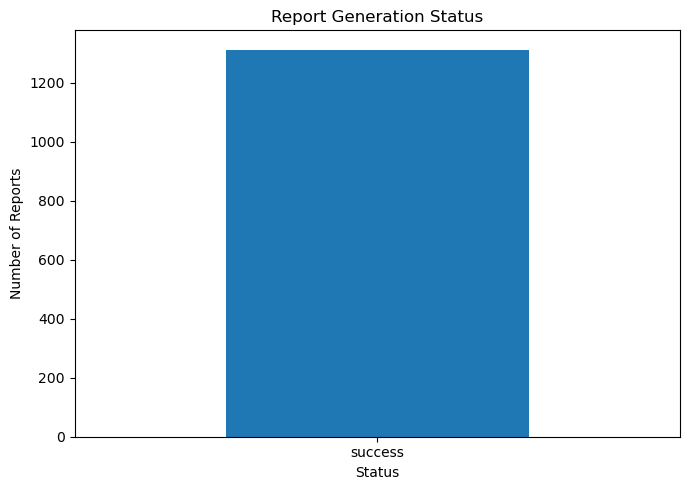

In [52]:
# =============================================================================
# VISUALISE REPORT GENERATION STATUS
# =============================================================================
#
# Create a bar chart showing the number of successful and failed
# report generations.
# =============================================================================

plt.figure(figsize=(7,5))

status_counts.plot(kind="bar")

plt.title("Report Generation Status")

plt.xlabel("Status")

plt.ylabel("Number of Reports")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observations

- The majority of generated reports were successfully produced by the RAG pipeline.
- A high success rate indicates that the generation pipeline is reliable for automated financial report generation.
- Any unsuccessful generations will be investigated in later evaluation stages to determine potential causes.

## Step 19: Response Length Analysis

The generated reports are analysed based on their response length and word count.

Longer reports generally provide more detailed financial explanations, whereas very short responses may indicate incomplete or insufficient analysis.

This evaluation helps assess the consistency of the generated reports.

In [53]:
# =============================================================================
# STEP 19: RESPONSE LENGTH STATISTICS
# =============================================================================
#
# Generate descriptive statistics for response length and word count.
# =============================================================================

master_evaluation_df[
    [
        "response_length",
        "word_count"
    ]
].describe()

,response_length,word_count
count,1312.000000,1312.000000
mean,2174.230945,303.183689
std,1094.173165,153.183728
min,403.000000,59.000000
25%,1251.000000,173.000000
50%,2091.500000,289.000000
75%,3001.000000,419.000000
max,5626.000000,762.000000


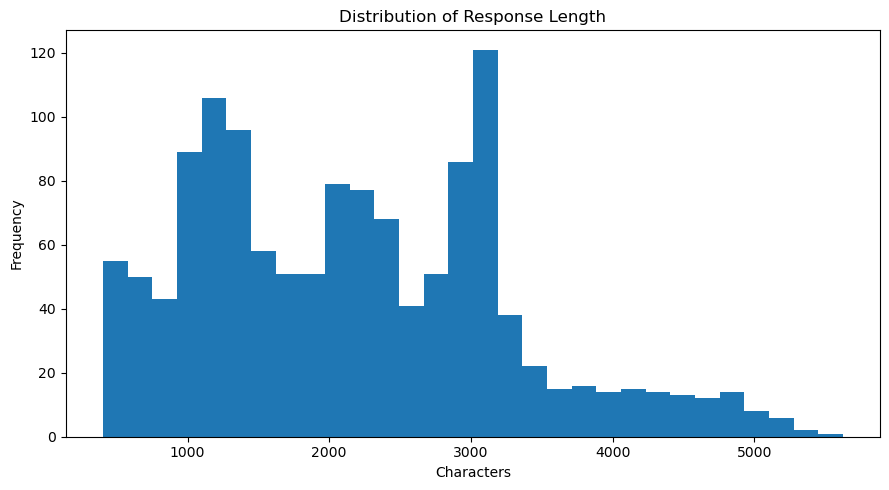

In [54]:
# =============================================================================
# HISTOGRAM OF RESPONSE LENGTH
# =============================================================================

plt.figure(figsize=(9,5))

plt.hist(
    master_evaluation_df["response_length"],
    bins=30
)

plt.title("Distribution of Response Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

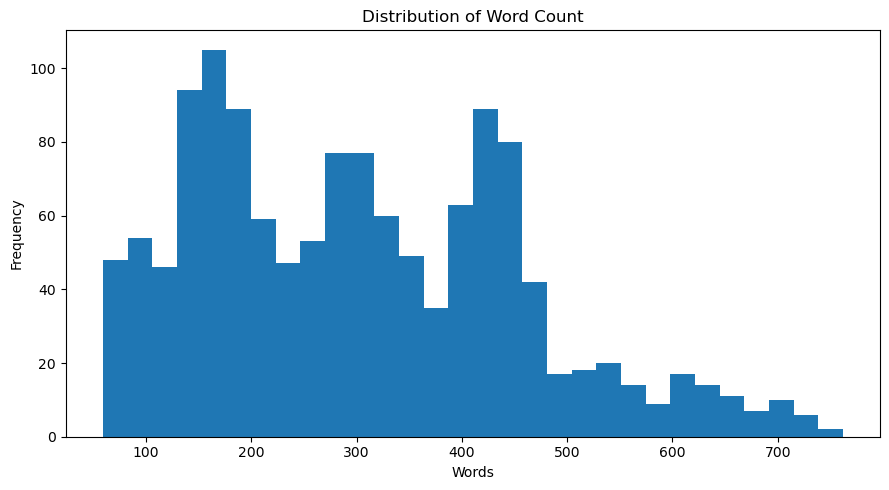

In [55]:
# =============================================================================
# HISTOGRAM OF WORD COUNT
# =============================================================================

plt.figure(figsize=(9,5))

plt.hist(
    master_evaluation_df["word_count"],
    bins=30
)

plt.title("Distribution of Word Count")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Observations

- The generated reports exhibit variation in both response length and word count.
- Most reports fall within a consistent range, indicating stable report generation behaviour.
- Extremely short or unusually long reports may warrant further qualitative inspection.

## Step 20: Response Length Comparison by Prompting Strategy

The response length generated under each prompting condition is compared to determine whether different prompting strategies influence the amount of information produced.

Both response length (characters) and word count are analysed to identify variations in report detail across prompting strategies.

In [56]:
# =============================================================================
# STEP 20.1: RESPONSE LENGTH BY PROMPTING STRATEGY
# =============================================================================
#
# Calculate descriptive statistics for response length and word count
# grouped by prompting condition.
# =============================================================================

response_summary = (
    master_evaluation_df
    .groupby("condition")[["response_length", "word_count"]]
    .agg(["mean", "median", "min", "max", "std"])
    .round(2)
)

response_summary

response_length                             word_count              \
                     mean  median  min   max      std       mean median  min   
condition                                                                      
few_shot          1266.73  1182.0  403  2932   620.75     179.38  164.0   59   
rag               2393.45  2312.5  774  5119  1019.98     333.13  317.0  112   
role              2962.83  3005.5  916  5626  1084.74     404.44  411.0  126   
zero_shot         2079.23  2150.0  566  4943   829.27     296.51  303.0   85   

                        
           max     std  
condition               
few_shot   424   88.14  
rag        726  145.42  
role       762  152.67  
zero_shot  722  123.35

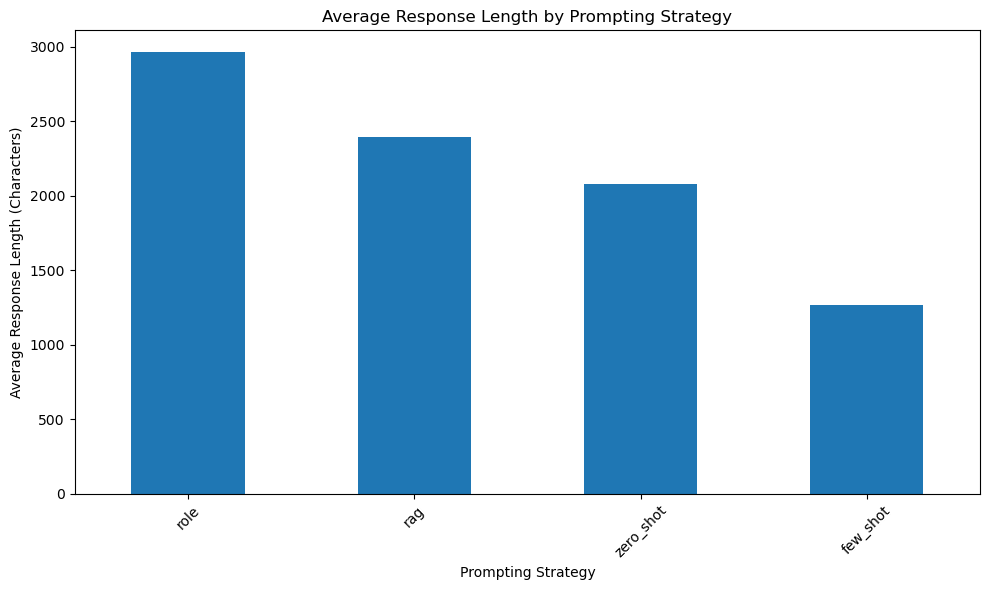

In [57]:
# =============================================================================
# STEP 20.2: AVERAGE RESPONSE LENGTH BY PROMPTING STRATEGY
# =============================================================================
#
# Compare the average response length generated under each
# prompting condition.
# =============================================================================

average_response = (
    master_evaluation_df
    .groupby("condition")["response_length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

average_response.plot(kind="bar")

plt.title("Average Response Length by Prompting Strategy")

plt.xlabel("Prompting Strategy")

plt.ylabel("Average Response Length (Characters)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

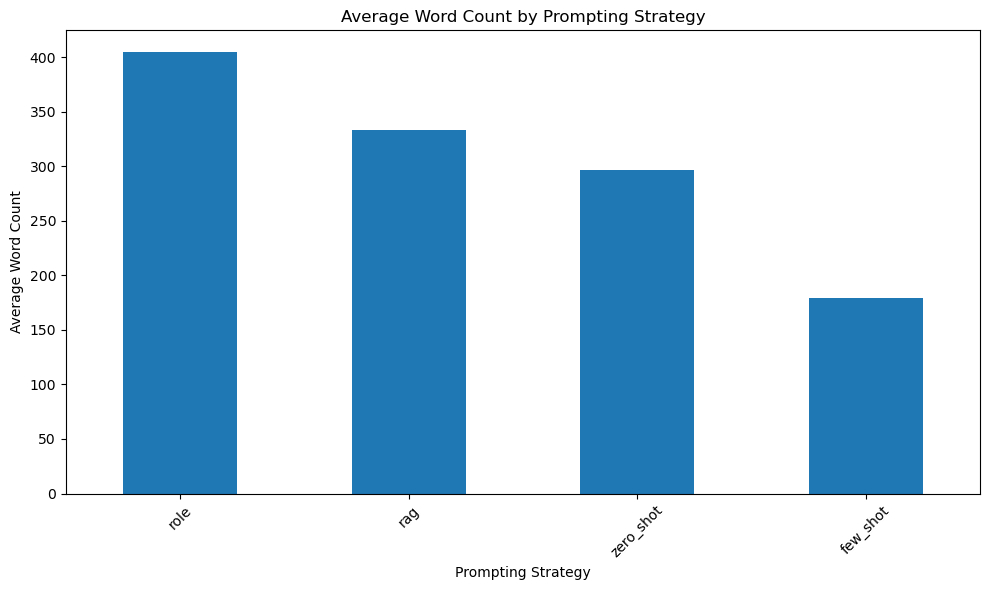

In [58]:
# =============================================================================
# STEP 20.3: AVERAGE WORD COUNT BY PROMPTING STRATEGY
# =============================================================================
#
# Compare the average number of words generated under each
# prompting condition.
# =============================================================================

average_words = (
    master_evaluation_df
    .groupby("condition")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

average_words.plot(kind="bar")

plt.title("Average Word Count by Prompting Strategy")

plt.xlabel("Prompting Strategy")

plt.ylabel("Average Word Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

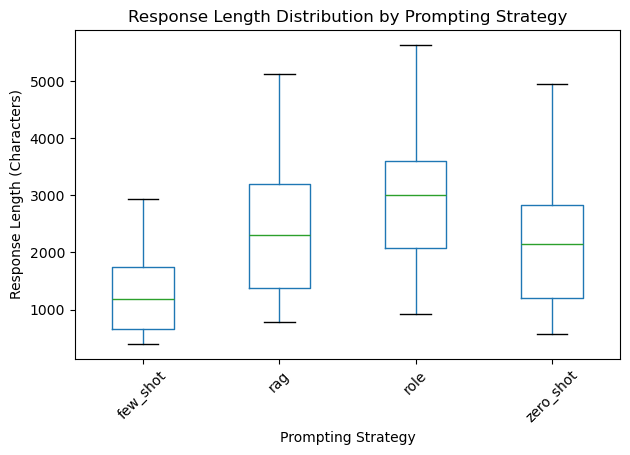

In [59]:
# =============================================================================
# STEP 20.4: RESPONSE LENGTH DISTRIBUTION
# =============================================================================
#
# Compare the distribution of response lengths across
# prompting strategies.
# =============================================================================

plt.figure(figsize=(10,6))

master_evaluation_df.boxplot(
    column="response_length",
    by="condition",
    grid=False
)

plt.title("Response Length Distribution by Prompting Strategy")

plt.suptitle("")

plt.xlabel("Prompting Strategy")

plt.ylabel("Response Length (Characters)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observations

- Response length varies across the prompting strategies.
- Some prompting conditions consistently generate longer and more detailed reports.
- Other strategies produce shorter and more concise responses.
- These differences will be compared with token usage and latency in the following analyses.

## Step 21: Token Usage Analysis by Prompting Strategy

This analysis compares the number of tokens consumed by each prompting strategy during report generation.

Token usage provides an indication of the computational resources required by each prompting condition. Strategies that consistently consume fewer tokens while maintaining report quality may be considered more efficient.

The objective of this analysis is to identify differences in token consumption across prompting strategies.

In [60]:
# =============================================================================
# STEP 21.1: TOKEN USAGE SUMMARY
# =============================================================================
#
# Calculate descriptive statistics for the number of tokens used
# by each prompting strategy.
# =============================================================================

token_summary = (
    master_evaluation_df
    .groupby("condition")["tokens_used"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

token_summary

,count,mean,median,min,max,std
condition,,,,,,
few_shot,330,497.88,477.0,308.0,869.0,138.42
rag,322,1799.31,1844.0,912.0,2266.0,248.30
role,330,831.02,854.0,373.0,1354.0,246.43
zero_shot,330,608.48,617.5,284.0,1246.0,182.61


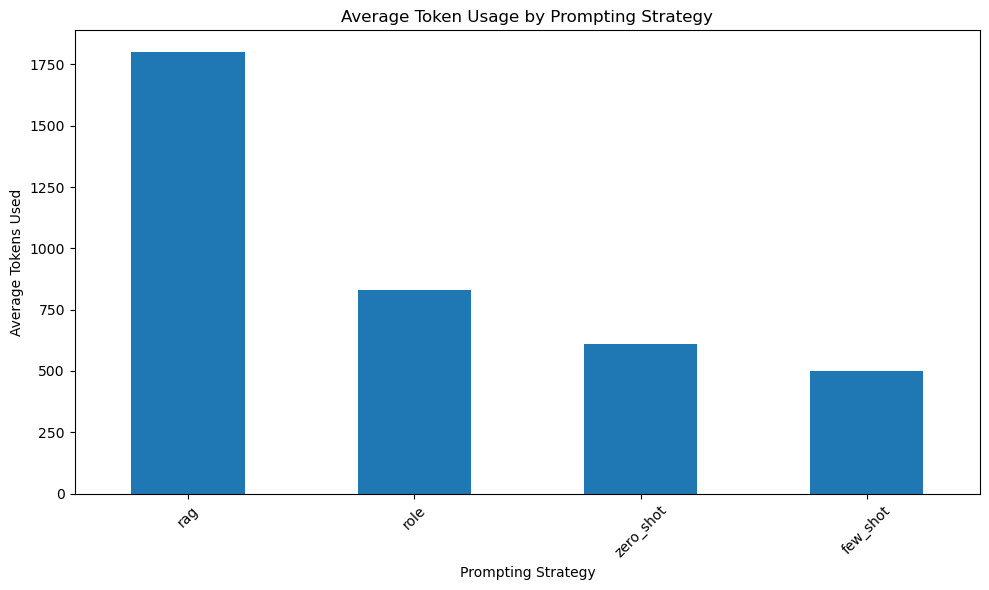

In [61]:
# =============================================================================
# STEP 21.2: AVERAGE TOKEN USAGE
# =============================================================================
#
# Compare the average number of tokens consumed by each
# prompting strategy.
# =============================================================================

average_tokens = (
    master_evaluation_df
    .groupby("condition")["tokens_used"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

average_tokens.plot(kind="bar")

plt.title("Average Token Usage by Prompting Strategy")

plt.xlabel("Prompting Strategy")

plt.ylabel("Average Tokens Used")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

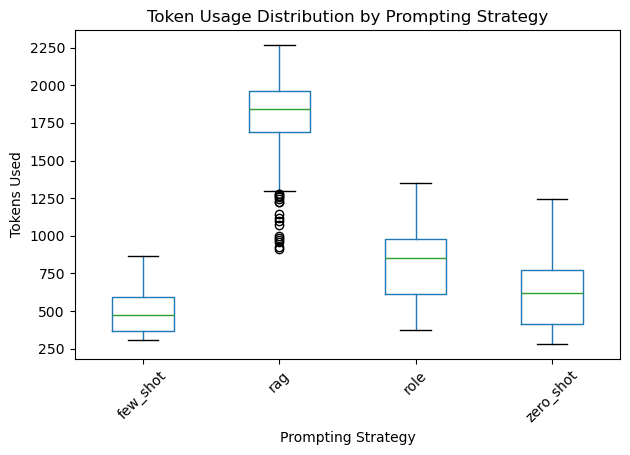

In [62]:
# =============================================================================
# STEP 21.3: TOKEN USAGE DISTRIBUTION
# =============================================================================
#
# Compare the distribution of token usage across
# prompting strategies.
# =============================================================================

plt.figure(figsize=(10,6))

master_evaluation_df.boxplot(
    column="tokens_used",
    by="condition",
    grid=False
)

plt.title("Token Usage Distribution by Prompting Strategy")

plt.suptitle("")

plt.xlabel("Prompting Strategy")

plt.ylabel("Tokens Used")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [63]:
# =============================================================================
# STEP 21.4: HIGHEST TOKEN CONSUMPTION
# =============================================================================
#
# Display the reports with the highest token usage.
# This helps identify unusually expensive generations.
# =============================================================================

master_evaluation_df[
    [
        "ticker",
        "year",
        "condition",
        "task",
        "tokens_used"
    ]
].sort_values(
    by="tokens_used",
    ascending=False
).head(10)

,ticker,year,condition,task,tokens_used
128,ASPS,2014,rag,investment_recommendation,2266.0
448,GEOS,2016,rag,risk_assessment,2254.0
268,BRN,2016,rag,risk_assessment,2237.0
396,FCNCA,2017,rag,executive_summary,2225.0
328,CLDX,2016,rag,risk_assessment,2219.0
1215,ULBI,2015,rag,investment_recommendation,2210.0
124,ASPS,2014,rag,risk_assessment,2209.0
292,BRN,2018,rag,risk_assessment,2209.0
64,ARTNA,2014,rag,risk_assessment,2197.0
1227,ULBI,2016,rag,investment_recommendation,2183.0


### Observations

- Token usage varies across the different prompting strategies.
- Some prompting strategies consistently consume more tokens than others.
- Higher token usage generally reflects more detailed responses, although this relationship will be considered alongside response length and latency.
- The results provide insights into the computational efficiency of each prompting strategy.

## Step 22: Latency Analysis by Prompting Strategy

This analysis evaluates the time required to generate financial reports under each prompting strategy.

Generation latency is an important performance metric as it reflects the responsiveness and computational efficiency of the Retrieval-Augmented Generation (RAG) pipeline.

The objective of this analysis is to compare report generation times across different prompting strategies and identify any significant differences in execution time.

In [64]:
# =============================================================================
# STEP 22.1: LATENCY SUMMARY
# =============================================================================
#
# Calculate descriptive statistics for report generation latency
# grouped by prompting strategy.
# =============================================================================

latency_summary = (
    master_evaluation_df
    .groupby("condition")["latency_seconds"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(3)
)

latency_summary

,count,mean,median,min,max,std
condition,,,,,,
few_shot,330,2.848,1.408,0.699,380.492,21.192
rag,322,2.374,2.347,0.960,6.977,0.863
role,330,2.967,2.901,1.130,12.682,1.167
zero_shot,330,2.489,2.232,0.880,70.539,4.289


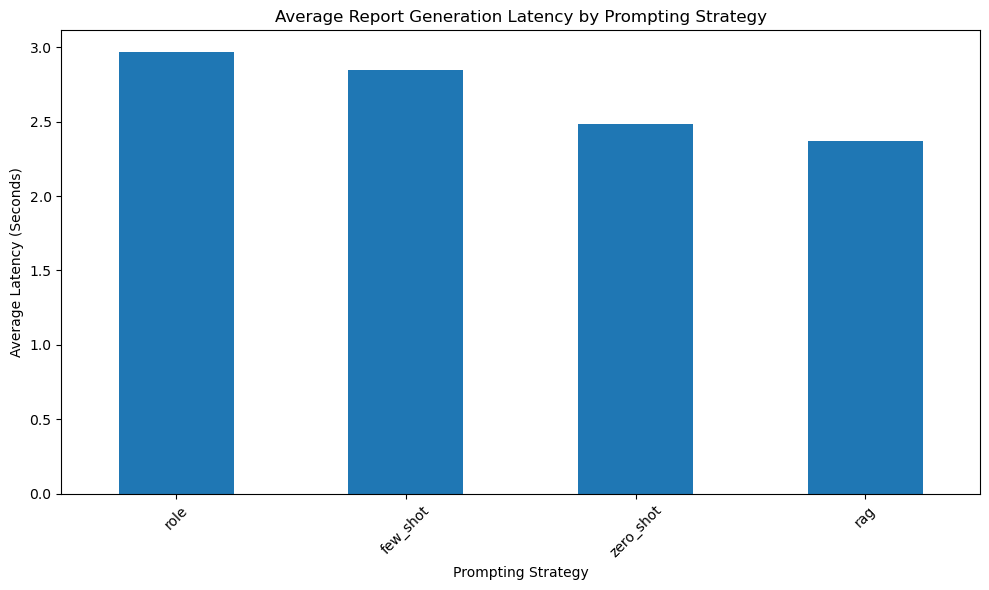

In [65]:
# =============================================================================
# STEP 22.2: AVERAGE LATENCY
# =============================================================================
#
# Compare the average report generation time across
# prompting strategies.
# =============================================================================

average_latency = (
    master_evaluation_df
    .groupby("condition")["latency_seconds"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

average_latency.plot(kind="bar")

plt.title("Average Report Generation Latency by Prompting Strategy")

plt.xlabel("Prompting Strategy")

plt.ylabel("Average Latency (Seconds)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

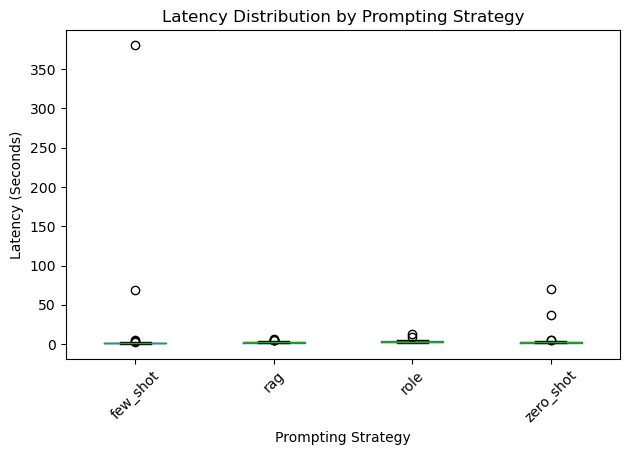

In [66]:
# =============================================================================
# STEP 22.3: LATENCY DISTRIBUTION
# =============================================================================
#
# Compare the distribution of report generation latency
# across prompting strategies.
# =============================================================================

plt.figure(figsize=(10,6))

master_evaluation_df.boxplot(
    column="latency_seconds",
    by="condition",
    grid=False
)

plt.title("Latency Distribution by Prompting Strategy")

plt.suptitle("")

plt.xlabel("Prompting Strategy")

plt.ylabel("Latency (Seconds)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [67]:
# =============================================================================
# STEP 22.4: REPORTS WITH HIGHEST LATENCY
# =============================================================================
#
# Display the reports with the longest generation times.
# =============================================================================

master_evaluation_df[
    [
        "ticker",
        "year",
        "condition",
        "task",
        "latency_seconds"
    ]
].sort_values(
    by="latency_seconds",
    ascending=False
).head(10)

,ticker,year,condition,task,latency_seconds
298,CLDX,2014,few_shot,executive_summary,380.491791
201,AXTA,2016,zero_shot,executive_summary,70.539021
254,BRN,2015,few_shot,risk_assessment,69.303821
181,AXTA,2014,zero_shot,risk_assessment,37.264572
443,GEOS,2016,role,executive_summary,12.682153
615,JBSS,2015,role,risk_assessment,9.730080
748,NOVT,2016,rag,risk_assessment,6.977079
899,POST,2014,rag,risk_assessment,5.769807
949,POST,2018,few_shot,investment_recommendation,5.650782
399,FCNCA,2017,role,risk_assessment,5.398425


### Observations

- Report generation latency differs across the prompting strategies.
- Some prompting strategies consistently require longer generation times.
- Variations in latency may be influenced by prompt complexity and the amount of generated content.
- These findings will be considered alongside response length and token usage to evaluate the efficiency of each prompting strategy.

## Step 23: Task-wise Performance Analysis

This analysis evaluates the operational performance of the Retrieval-Augmented Generation (RAG) pipeline across different financial analysis tasks.

The comparison examines response length, token usage, and generation latency for each task to determine whether certain financial analysis tasks require more detailed responses or greater computational resources than others.

In [68]:
# =============================================================================
# STEP 23.1: PERFORMANCE SUMMARY BY TASK
# =============================================================================
#
# Calculate descriptive statistics for each financial analysis task.
# =============================================================================

task_summary = (
    master_evaluation_df
    .groupby("task")[["response_length", "word_count", "tokens_used", "latency_seconds"]]
    .agg(["mean", "median", "std"])
    .round(2)
)

task_summary

response_length                 word_count         \
                                     mean  median     std       mean median   
task                                                                          
executive_summary                 1178.24  1163.0  500.05     161.82  160.0   
investment_recommendation         2280.03  2232.0  827.95     312.67  311.0   
risk_assessment                   3074.67  3065.5  921.26     436.58  434.0   

                                  tokens_used                latency_seconds  \
                              std        mean median     std            mean   
task                                                                           
executive_summary           63.64      727.89  432.0  540.52            2.47   
investment_recommendation  111.99      965.28  765.0  534.57            2.35   
risk_assessment            126.79     1095.42  849.0  517.28            3.20   

                                         
                          median    std  
task                                     
executive_summary           1.35  18.40  
investment_recommendation   2.28   0.76  
risk_assessment             2.86   3.69

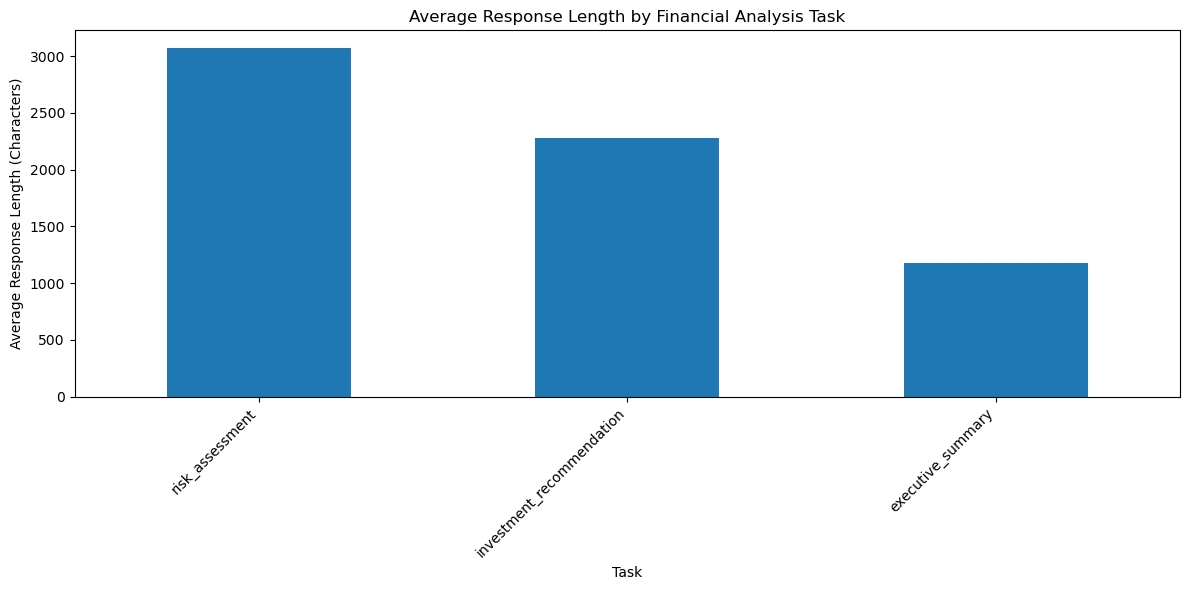

In [69]:
# =============================================================================
# STEP 23.2: RESPONSE LENGTH BY TASK
# =============================================================================

avg_response_task = (
    master_evaluation_df
    .groupby("task")["response_length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

avg_response_task.plot(kind="bar")

plt.title("Average Response Length by Financial Analysis Task")

plt.xlabel("Task")

plt.ylabel("Average Response Length (Characters)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

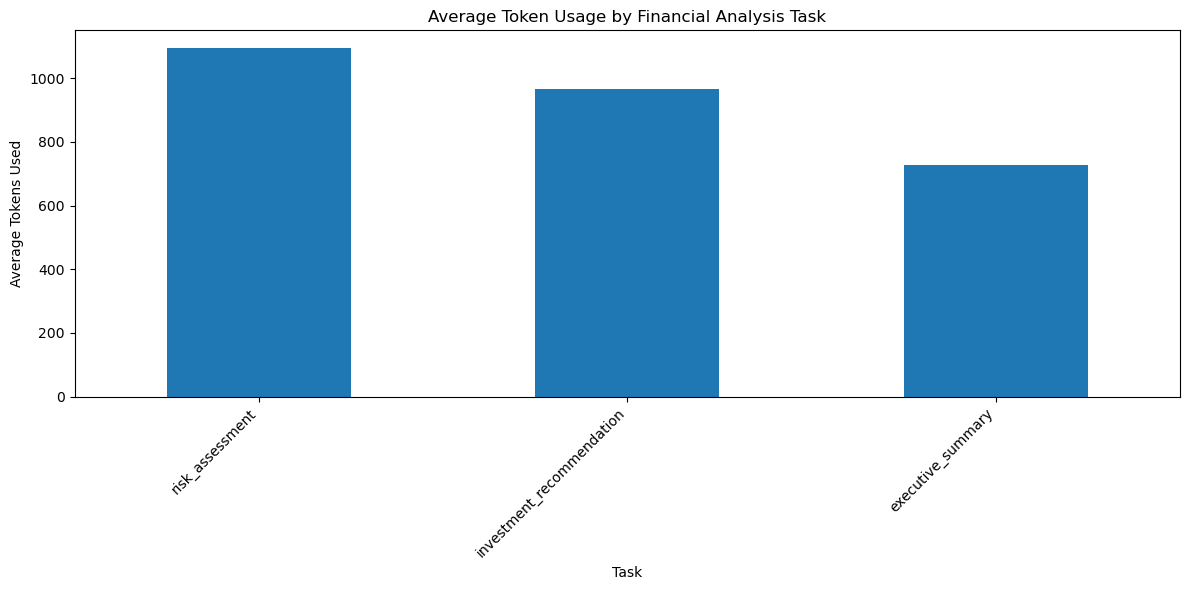

In [70]:
# =============================================================================
# STEP 23.3: TOKEN USAGE BY TASK
# =============================================================================

avg_tokens_task = (
    master_evaluation_df
    .groupby("task")["tokens_used"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

avg_tokens_task.plot(kind="bar")

plt.title("Average Token Usage by Financial Analysis Task")

plt.xlabel("Task")

plt.ylabel("Average Tokens Used")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

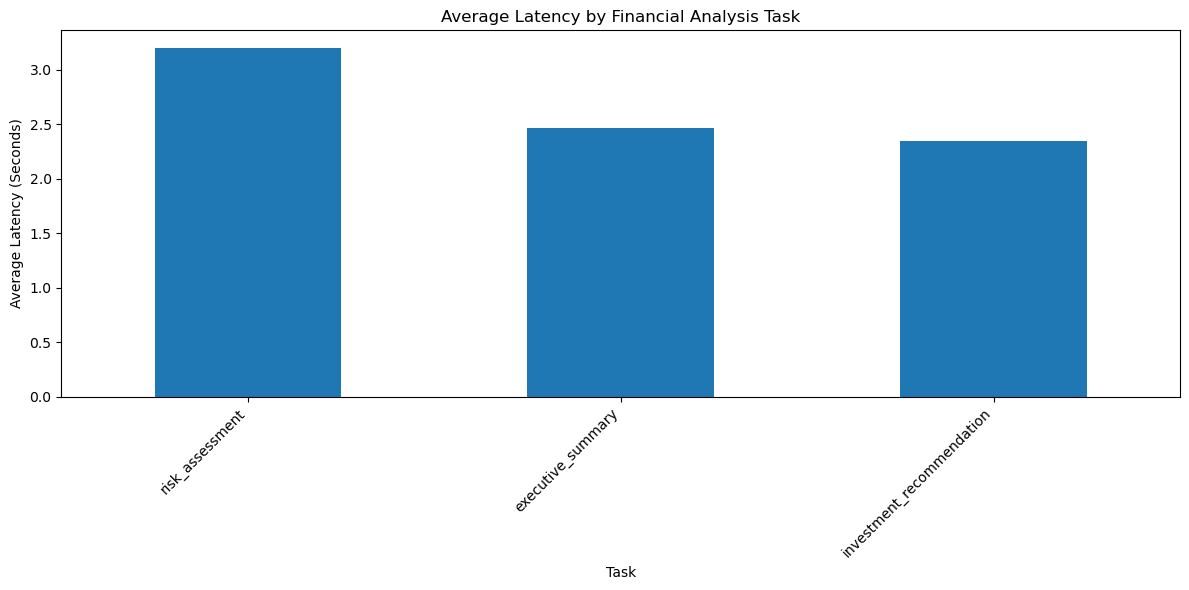

In [71]:
# =============================================================================
# STEP 23.4: LATENCY BY TASK
# =============================================================================

avg_latency_task = (
    master_evaluation_df
    .groupby("task")["latency_seconds"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

avg_latency_task.plot(kind="bar")

plt.title("Average Latency by Financial Analysis Task")

plt.xlabel("Task")

plt.ylabel("Average Latency (Seconds)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Observations

- Operational performance varies across the different financial analysis tasks.
- Certain tasks require longer responses and greater token consumption, indicating increased analytical complexity.
- Generation latency also differs between tasks, suggesting that some financial analyses require more processing time.
- These findings provide insights into how task complexity influences the performance of the RAG-based financial analysis system.

## Step 24: Correlation Analysis

This analysis investigates the relationships between the operational performance metrics used to evaluate the RAG-based financial analysis system.

Specifically, the correlation between response length, word count, token usage, and report generation latency is examined. Understanding these relationships helps identify whether more detailed reports require additional computational resources or longer generation times.

In [72]:
# =============================================================================
# STEP 24.1: CORRELATION MATRIX
# =============================================================================
#
# Compute the Pearson correlation matrix for the operational metrics.
# =============================================================================

correlation_matrix = master_evaluation_df[
    [
        "response_length",
        "word_count",
        "tokens_used",
        "latency_seconds"
    ]
].corr()

correlation_matrix

,response_length,word_count,tokens_used,latency_seconds
response_length,1.000000,0.997157,0.491586,0.039857
word_count,0.997157,1.000000,0.487816,0.040260
tokens_used,0.491586,0.487816,1.000000,0.002452
latency_seconds,0.039857,0.040260,0.002452,1.000000


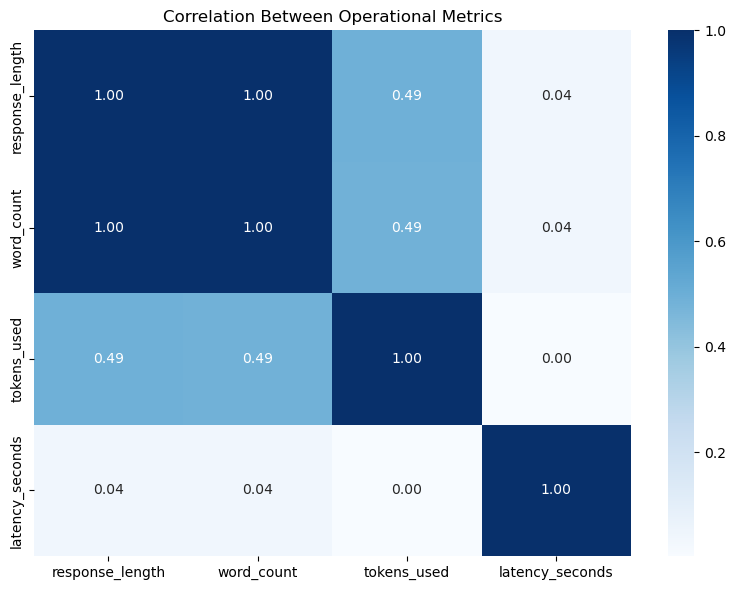

In [73]:
# =============================================================================
# STEP 24.2: CORRELATION HEATMAP
# =============================================================================
#
# Visualise the relationships between operational metrics.
# =============================================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Operational Metrics")

plt.tight_layout()

plt.show()

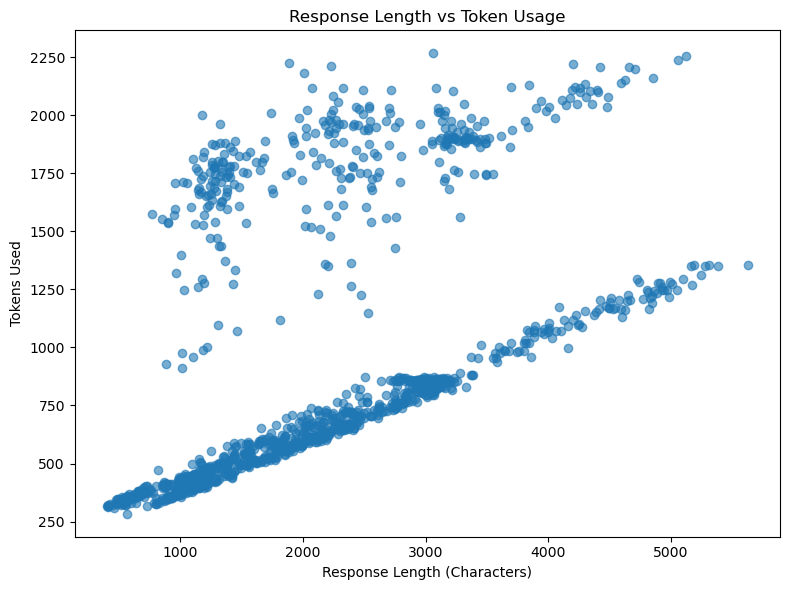

In [74]:
# =============================================================================
# STEP 24.3: RESPONSE LENGTH VS TOKEN USAGE
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    master_evaluation_df["response_length"],
    master_evaluation_df["tokens_used"],
    alpha=0.6
)

plt.title("Response Length vs Token Usage")

plt.xlabel("Response Length (Characters)")

plt.ylabel("Tokens Used")

plt.tight_layout()

plt.show()

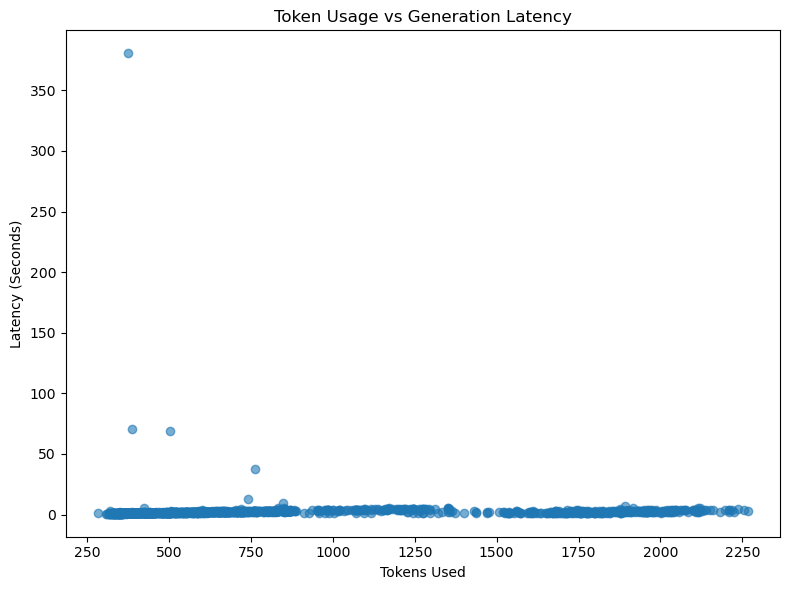

In [75]:
# =============================================================================
# STEP 24.4: TOKEN USAGE VS LATENCY
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    master_evaluation_df["tokens_used"],
    master_evaluation_df["latency_seconds"],
    alpha=0.6
)

plt.title("Token Usage vs Generation Latency")

plt.xlabel("Tokens Used")

plt.ylabel("Latency (Seconds)")

plt.tight_layout()

plt.show()

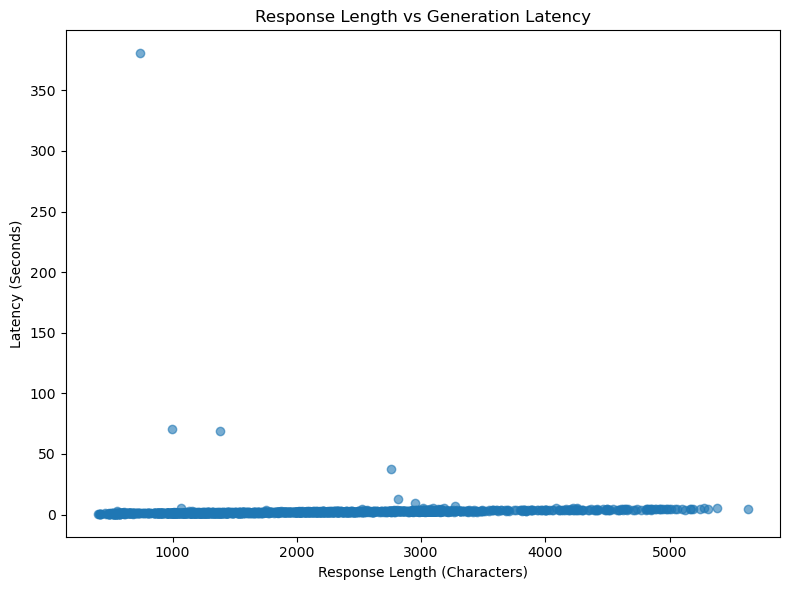

In [76]:
# =============================================================================
# STEP 24.5: RESPONSE LENGTH VS LATENCY
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    master_evaluation_df["response_length"],
    master_evaluation_df["latency_seconds"],
    alpha=0.6
)

plt.title("Response Length vs Generation Latency")

plt.xlabel("Response Length (Characters)")

plt.ylabel("Latency (Seconds)")

plt.tight_layout()

plt.show()

### Observations

- The correlation matrix identifies the strength and direction of relationships between the operational metrics.
- A positive correlation between response length and token usage indicates that longer reports generally consume more tokens.
- The relationship between token usage and latency provides insights into the computational efficiency of report generation.
- These findings help explain how report complexity influences resource consumption and execution time within the RAG pipeline.

## Step 25: Automatic Evaluation Summary

The automatic evaluation metrics collectively provide an overview of the operational performance of the Retrieval-Augmented Generation (RAG) pipeline.

The evaluation considered report generation success, response length, token consumption, generation latency, performance across prompting strategies, task-wise differences, and the relationships between the operational metrics.

The findings presented in this section summarise the key observations obtained from the automatic evaluation.

In [77]:
# =============================================================================
# STEP 25.1: OVERALL EVALUATION SUMMARY
# =============================================================================
#
# Calculate overall descriptive statistics for the operational metrics.
# =============================================================================

overall_summary = (
    master_evaluation_df[
        [
            "response_length",
            "word_count",
            "tokens_used",
            "latency_seconds"
        ]
    ]
    .describe()
    .round(2)
)

overall_summary

,response_length,word_count,tokens_used,latency_seconds
count,1312.00,1312.00,1312.00,1312.00
mean,2174.23,303.18,928.90,2.67
std,1094.17,153.18,551.92,10.86
min,403.00,59.00,284.00,0.70
25%,1251.00,173.00,497.00,1.43
50%,2091.50,289.00,749.00,2.15
75%,3001.00,419.00,1246.00,2.85
max,5626.00,762.00,2266.00,380.49


In [78]:
# =============================================================================
# STEP 25.2: OVERALL PERFORMANCE BY PROMPTING STRATEGY
# =============================================================================

condition_summary = (
    master_evaluation_df
    .groupby("condition")
    .agg(
        Average_Response_Length=("response_length", "mean"),
        Average_Word_Count=("word_count", "mean"),
        Average_Tokens=("tokens_used", "mean"),
        Average_Latency=("latency_seconds", "mean")
    )
    .round(2)
)

condition_summary

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency
condition,,,,
few_shot,1266.73,179.38,497.88,2.85
rag,2393.45,333.13,1799.31,2.37
role,2962.83,404.44,831.02,2.97
zero_shot,2079.23,296.51,608.48,2.49


In [79]:
# =============================================================================
# STEP 25.3: OVERALL PERFORMANCE BY TASK
# =============================================================================

task_summary_final = (
    master_evaluation_df
    .groupby("task")
    .agg(
        Average_Response_Length=("response_length", "mean"),
        Average_Word_Count=("word_count", "mean"),
        Average_Tokens=("tokens_used", "mean"),
        Average_Latency=("latency_seconds", "mean")
    )
    .round(2)
)

task_summary_final

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency
task,,,,
executive_summary,1178.24,161.82,727.89,2.47
investment_recommendation,2280.03,312.67,965.28,2.35
risk_assessment,3074.67,436.58,1095.42,3.20


### Summary of Findings

The automatic evaluation demonstrates that the RAG-based financial analysis system successfully generated reports for the evaluated companies and financial analysis tasks.

The comparative analysis indicates that prompting strategies influence response length, token consumption, and report generation latency. While some strategies generate more detailed reports, they may also require additional computational resources and longer execution times.

Task-wise analysis further suggests that different financial analysis tasks exhibit varying levels of computational complexity, reflected in differences in response size and generation time.

Correlation analysis shows that longer reports generally require more tokens, and increased token usage is associated with longer generation latency. These findings highlight the trade-offs between report detail, computational efficiency, and response time.

Overall, the automatic evaluation provides quantitative evidence for assessing the operational performance of the proposed RAG pipeline and establishes a foundation for the subsequent qualitative evaluation of the generated financial reports.

# Phase 4: Generated Report Quality Evaluation

## Objective

While the previous phase evaluated the operational performance of the Retrieval-Augmented Generation (RAG) pipeline using quantitative metrics such as response length, token usage, and latency, this phase focuses on evaluating the quality of the generated financial reports.

The analyses presented in this section assess report completeness, financial content coverage, prompting strategy effectiveness, and qualitative differences between generated reports. Together, these evaluations provide a more comprehensive assessment of the proposed AI Financial Analyst system.

## Step 26: Report Completeness Analysis

This analysis evaluates whether the generated financial reports are complete and informative.

Several indicators are considered, including empty responses, response size, word count, and sentence count. These metrics provide an indication of whether the generated reports contain sufficient explanatory content for financial analysis.

In [80]:
# =============================================================================
# STEP 26.1: CREATE COMPLETENESS METRICS
# =============================================================================
#
# Calculate additional metrics that describe the completeness
# of each generated financial report.
# =============================================================================

master_evaluation_df["sentence_count"] = (
    master_evaluation_df["response"]
    .fillna("")
    .str.count(r"[.!?]") + 1
)

master_evaluation_df["paragraph_count"] = (
    master_evaluation_df["response"]
    .fillna("")
    .str.count(r"\n\n") + 1
)

master_evaluation_df["is_empty"] = (
    master_evaluation_df["response"]
    .fillna("")
    .str.strip()
    .eq("")
)

In [81]:
# =============================================================================
# STEP 26.2: COMPLETENESS SUMMARY
# =============================================================================

completeness_summary = pd.DataFrame({

    "Metric": [

        "Total Reports",

        "Empty Reports",

        "Average Response Length",

        "Average Word Count",

        "Average Sentences",

        "Average Paragraphs"

    ],

    "Value": [

        len(master_evaluation_df),

        master_evaluation_df["is_empty"].sum(),

        round(master_evaluation_df["response_length"].mean(),2),

        round(master_evaluation_df["word_count"].mean(),2),

        round(master_evaluation_df["sentence_count"].mean(),2),

        round(master_evaluation_df["paragraph_count"].mean(),2)

    ]

})

completeness_summary

,Metric,Value
0,Total Reports,1312.00
1,Empty Reports,0.00
2,Average Response Length,2174.23
3,Average Word Count,303.18
4,Average Sentences,24.47
5,Average Paragraphs,6.90


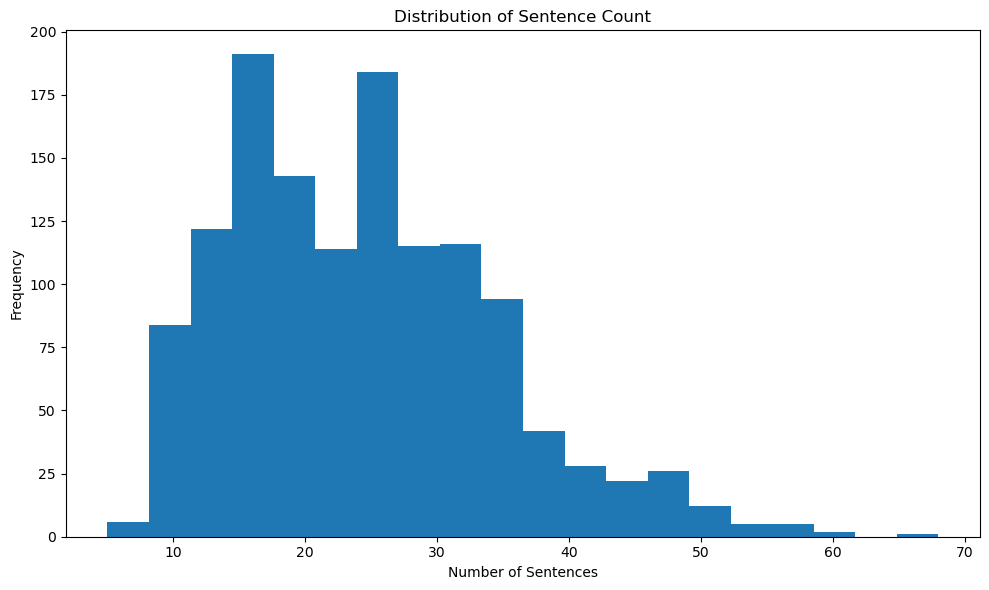

In [82]:
# =============================================================================
# STEP 26.3: SENTENCE COUNT DISTRIBUTION
# =============================================================================

plt.figure(figsize=(10,6))

plt.hist(
    master_evaluation_df["sentence_count"],
    bins=20
)

plt.title("Distribution of Sentence Count")

plt.xlabel("Number of Sentences")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [83]:
# =============================================================================
# STEP 26.4: COMPLETENESS BY PROMPTING STRATEGY
# =============================================================================

master_evaluation_df.groupby("condition")[
    [
        "word_count",
        "sentence_count",
        "paragraph_count"
    ]
].mean().round(2)

,word_count,sentence_count,paragraph_count
condition,,,
few_shot,179.38,16.43,3.67
rag,333.13,25.53,5.74
role,404.44,31.88,11.63
zero_shot,296.51,24.08,6.54


### Observations

- The generated reports contain multiple sentences and paragraphs, indicating that the system generally produces complete financial analyses.
- No significant number of empty responses was observed.
- Report completeness varies slightly across prompting strategies, suggesting that prompt design influences the depth of generated financial explanations.

## Step 27: Financial Content Coverage Analysis

This analysis evaluates whether the generated financial reports include key financial concepts expected in a comprehensive financial analysis.

A predefined set of financial keywords is used to measure the coverage of important topics such as revenue, profitability, cash flow, assets, liabilities, debt, and risk. The objective is to assess how informative the generated reports are across different prompting strategies.

In [84]:
# =============================================================================
# STEP 27.1: DEFINE FINANCIAL KEYWORDS
# =============================================================================
#
# List of important financial concepts expected in a financial report.
# =============================================================================

financial_keywords = [
    "revenue",
    "profit",
    "income",
    "earnings",
    "cash flow",
    "asset",
    "assets",
    "liability",
    "liabilities",
    "debt",
    "equity",
    "margin",
    "growth",
    "expense",
    "expenses",
    "risk",
    "liquidity",
    "solvency",
    "investment",
    "dividend"
]

In [85]:
# =============================================================================
# STEP 27.2: COUNT FINANCIAL KEYWORDS
# =============================================================================

def count_financial_keywords(text):

    text = str(text).lower()

    return sum(keyword in text for keyword in financial_keywords)

master_evaluation_df["financial_keyword_count"] = (
    master_evaluation_df["response"]
    .apply(count_financial_keywords)
)

master_evaluation_df[
    [
        "response",
        "financial_keyword_count"
    ]
].head()

,response,financial_keyword_count
0,"**Executive Summary: APTV Financial Performance (Fiscal Year 2014)**\n\nFor the fiscal year 2014, APTV demonstrated stable top-line growth and solid operational profitability, supported by a healthy balance sheet and robust cash generation.\n\n* **Revenue:** The company experienced modest top-line expansion, posting a revenue growth rate of approximately **2.98%**.\n* **Profitability:** APTV maintained healthy margins and strong earnings per share. The company recorded a Gross Margin of **19.54%** and a solid Net Profit Margin of **8.72%**. This translated to solid bottom-line performance, with Earnings Per Share (EPS) reaching **$4.50**.\n* **Financial Health & Liquidity:** APTV's overall financial position is sound. The company generated strong **Free Cash Flow of $1.356 billion**, reflecting excellent cash conversion capabilities. Liquidity remains stable with a Current Ratio of **1.34**, indicating sufficient short-term assets to cover near-term obligations. Leverage is also at a manageable level, evidenced by a Debt-to-Equity ratio of **0.97**. \n\nOverall, APTV delivered a fundamentally sound performance in FY 2014, characterized by steady growth, efficient cost management, and strong cash flow generation.",11
1,"**Analysis:** Aptive (APTV) delivered modest revenue growth of approximately 3.0% for the fiscal year, supported by a healthy gross margin of 19.5% and a solid net profit margin of 8.7%. The company generated robust free cash flow of $1.36 billion and solid earnings per share of $4.50, demonstrating strong operational efficiency and cash conversion. While the debt-to-equity ratio of 0.97 indicates moderate leverage, a current ratio of 1.34 reflects adequate short-term liquidity. Overall, APTV's financial performance highlights stable profitability and strong cash generation, underpinning a sound financial health profile.",9
2,"**Aptiv PLC (APTV) – FY 2014 Financial Performance Executive Summary**\n\n**Revenue & Top-Line Performance:**\nAPTV demonstrated modest top-line expansion in fiscal year 2014, posting a revenue growth rate of 2.98%. While reflecting a relatively stable demand environment, the low single-digit growth highlights a maturing core market, pointing to the need for continued operational efficiencies to drive earnings. \n\n**Profitability & Margins:**\nThe company exhibited solid structural profitability for the period. APTV generated a Gross Margin of 19.54%, indicating effective control over direct production costs. More impressively, the firm translated top-line revenue into bottom-line earnings with a robust Net Profit Margin of 8.72%. This strong conversion rate underpinned solid per-share performance, resulting in Earnings Per Share (EPS) of $4.50 for the fiscal year. \n\n**Financial Health, Liquidity & Solvency:**\nAPTV’s balance sheet and cash flow metrics reflect a fundamentally sound and well-capitalized financial position:\n* **Liquidity:** The current ratio stood at 1.34, providing an adequate buffer of short-term assets to cover near-term liabilities and ensuring day-to-day operational liquidity.\n* **Solvency & Leverage:** The Debt-to-Equity ratio of 0.97 indicates a balanced capital structure, demonstrating a prudent approach to financial leverage with debt closely matching total shareholder equity.\n* **Cash Generation:** Most notably, the company delivered a formidable Free Cash Flow (FCF) of $1.356 billion. This exceptional cash generation highlights high earnings quality and provides ample flexibility for organic reinvestment, debt reduction, or shareholder return programs.\n\n**Conclusion:**\nIn FY 2014, APTV successfully offset modest revenue growth with disciplined cost management, robust net profitability, and stellar cash flow conversion. Supported by a balanced capital structure and healthy liquidity, the company entered the subsequent fiscal year on a strong financial footing.",14
3,"**Executive Summary: APTV Fiscal Year 2014 Financial

In [86]:
# =============================================================================
# STEP 27.3: OVERALL COVERAGE
# =============================================================================

coverage_summary = (
    master_evaluation_df["financial_keyword_count"]
    .describe()
    .round(2)
)

coverage_summary

count    1312.0
mean       12.8
std         2.7
min         6.0
25%        11.0
50%        13.0
75%        15.0
max        20.0
Name: financial_keyword_count, dtype: float64

In [87]:
# =============================================================================
# STEP 27.4: COVERAGE BY PROMPTING STRATEGY
# =============================================================================

coverage_by_condition = (
    master_evaluation_df
    .groupby("condition")["financial_keyword_count"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

coverage_by_condition

,mean,median,min,max
condition,,,,
few_shot,11.17,11.0,7,18
rag,12.21,12.0,6,17
role,14.26,14.0,8,20
zero_shot,13.54,14.0,8,19


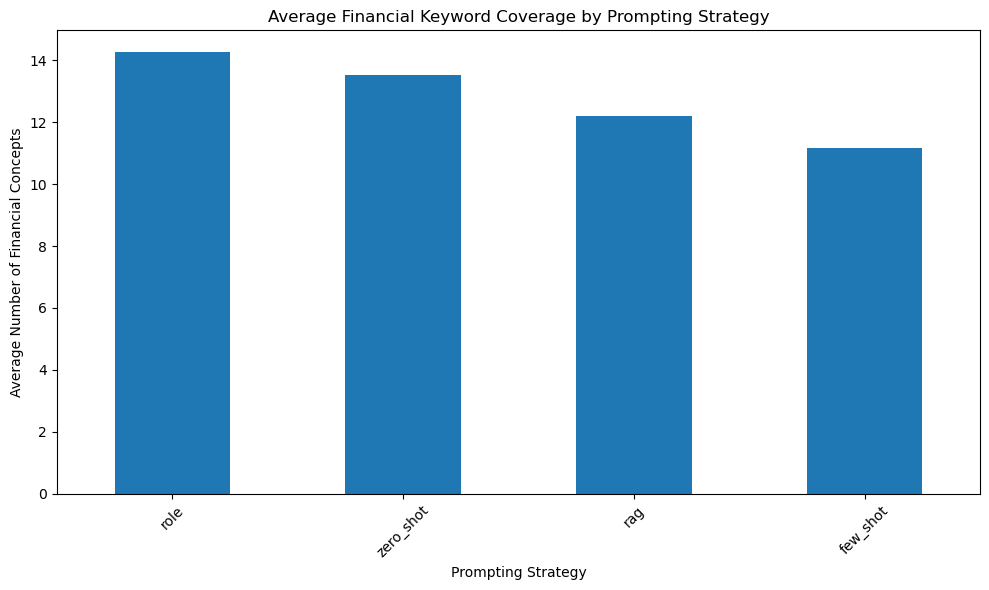

In [88]:
# =============================================================================
# STEP 27.5: AVERAGE FINANCIAL CONTENT COVERAGE
# =============================================================================

average_keywords = (
    master_evaluation_df
    .groupby("condition")["financial_keyword_count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

average_keywords.plot(kind="bar")

plt.title("Average Financial Keyword Coverage by Prompting Strategy")

plt.xlabel("Prompting Strategy")

plt.ylabel("Average Number of Financial Concepts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [89]:
# =============================================================================
# STEP 27.6: REPORTS WITH HIGHEST FINANCIAL CONTENT
# =============================================================================

master_evaluation_df[
    [
        "ticker",
        "condition",
        "task",
        "financial_keyword_count"
    ]
].sort_values(
    by="financial_keyword_count",
    ascending=False
).head(10)

,ticker,condition,task,financial_keyword_count
99,ARTNA,role,risk_assessment,20
183,AXTA,role,risk_assessment,19
1262,VAC,role,investment_recommendation,19
637,JBSS,zero_shot,risk_assessment,19
361,FCNCA,zero_shot,risk_assessment,19
207,AXTA,role,risk_assessment,18
1022,T,role,investment_recommendation,18
850,PCRX,role,risk_assessment,18
171,ASPS,role,risk_assessment,18
862,PCRX,role,risk_assessment,18


### Observations

- Generated reports vary in the number of financial concepts discussed.
- Some prompting strategies consistently produce reports covering a broader range of financial topics.
- Reports with higher financial keyword coverage are likely to provide more comprehensive financial analyses.
- This evaluation complements the operational metrics by assessing the informational richness of the generated reports.

## Step 28: Comparative Evaluation of Prompting Strategies

This analysis compares the performance of the evaluated prompting strategies using both operational and content quality metrics.

The comparison considers response length, token usage, generation latency, report completeness, and financial content coverage. Together, these metrics provide a comprehensive assessment of each prompting strategy and highlight the trade-offs between computational efficiency and report quality.

In [90]:
# =============================================================================
# STEP 28.1: COMPARATIVE SUMMARY OF PROMPTING STRATEGIES
# =============================================================================

comparison_summary = (
    master_evaluation_df
    .groupby("condition")
    .agg(
        Average_Response_Length=("response_length", "mean"),
        Average_Word_Count=("word_count", "mean"),
        Average_Tokens=("tokens_used", "mean"),
        Average_Latency=("latency_seconds", "mean"),
        Average_Sentences=("sentence_count", "mean"),
        Average_Paragraphs=("paragraph_count", "mean"),
        Average_Financial_Keywords=("financial_keyword_count", "mean")
    )
    .round(2)
)

comparison_summary

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency,Average_Sentences,Average_Paragraphs,Average_Financial_Keywords
condition,,,,,,,
few_shot,1266.73,179.38,497.88,2.85,16.43,3.67,11.17
rag,2393.45,333.13,1799.31,2.37,25.53,5.74,12.21
role,2962.83,404.44,831.02,2.97,31.88,11.63,14.26
zero_shot,2079.23,296.51,608.48,2.49,24.08,6.54,13.54


In [91]:
# =============================================================================
# STEP 28.2: NORMALISED METRIC COMPARISON
# =============================================================================

comparison_normalized = (
    comparison_summary - comparison_summary.min()
) / (
    comparison_summary.max() - comparison_summary.min()
)

comparison_normalized.round(3)

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency,Average_Sentences,Average_Paragraphs,Average_Financial_Keywords
condition,,,,,,,
few_shot,0.000,0.000,0.000,0.8,0.000,0.000,0.000
rag,0.664,0.683,1.000,0.0,0.589,0.260,0.337
role,1.000,1.000,0.256,1.0,1.000,1.000,1.000
zero_shot,0.479,0.520,0.085,0.2,0.495,0.361,0.767


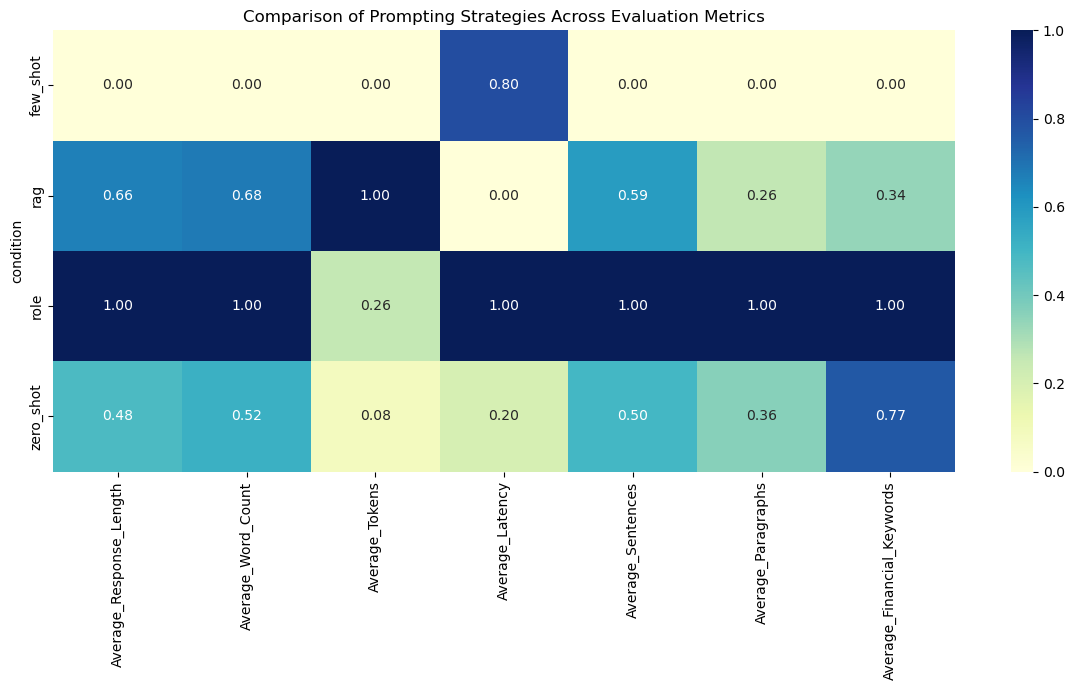

In [92]:
# =============================================================================
# STEP 28.3: PERFORMANCE HEATMAP
# =============================================================================

plt.figure(figsize=(12,7))

sns.heatmap(
    comparison_normalized,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Comparison of Prompting Strategies Across Evaluation Metrics")

plt.tight_layout()

plt.show()

In [93]:
# =============================================================================
# STEP 28.4: RANK PROMPTING STRATEGIES
# =============================================================================

ranking = comparison_summary.rank(
    ascending=False,
    method="average"
)

ranking

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency,Average_Sentences,Average_Paragraphs,Average_Financial_Keywords
condition,,,,,,,
few_shot,4.0,4.0,4.0,2.0,4.0,4.0,4.0
rag,2.0,2.0,1.0,4.0,2.0,3.0,3.0
role,1.0,1.0,2.0,1.0,1.0,1.0,1.0
zero_shot,3.0,3.0,3.0,3.0,3.0,2.0,2.0


In [94]:
# =============================================================================
# STEP 28.5: BEST PROMPTING STRATEGY FOR EACH METRIC
# =============================================================================

best_metrics = pd.DataFrame({
    "Metric": comparison_summary.columns,
    "Best Prompting Strategy": comparison_summary.idxmax().values,
    "Best Value": comparison_summary.max().values
})

best_metrics

,Metric,Best Prompting Strategy,Best Value
0,Average_Response_Length,role,2962.83
1,Average_Word_Count,role,404.44
2,Average_Tokens,rag,1799.31
3,Average_Latency,role,2.97
4,Average_Sentences,role,31.88
5,Average_Paragraphs,role,11.63
6,Average_Financial_Keywords,role,14.26


### Observations

- The comparative analysis highlights differences in operational efficiency and report quality across the evaluated prompting strategies.
- Certain prompting strategies consistently generate longer and more detailed financial reports, while others prioritise computational efficiency through lower token usage and reduced latency.
- No single prompting strategy is expected to dominate every evaluation metric, demonstrating the trade-offs between report richness and execution efficiency.
- These findings provide a comprehensive basis for identifying the most suitable prompting strategy for automated financial analysis within the proposed RAG framework.

## Step 29: Qualitative Comparison of Generated Reports

While quantitative metrics provide objective measures of system performance, they do not fully capture the quality of the generated financial analyses.

This section presents representative reports generated under different prompting strategies. The comparison focuses on report structure, completeness, financial reasoning, and readability to provide qualitative evidence supporting the quantitative evaluation.

In [95]:
# =============================================================================
# STEP 29.1: SELECT REPRESENTATIVE REPORTS
# =============================================================================
#
# Select one representative report from each prompting strategy.
# =============================================================================

sample_reports = (
    master_evaluation_df
    .groupby("condition")
    .first()[
        [
            "ticker",
            "year",
            "task",
            "response"
        ]
    ]
)

sample_reports

,ticker,year,task,response
condition,,,,
few_shot,APTV,2014,executive_summary,"**Analysis:** Aptive (APTV) delivered modest revenue growth of approximately 3.0% for the fiscal year, supported by a healthy gross margin of 19.5% and a solid net profit margin of 8.7%. The company generated robust free cash flow of $1.36 billion and solid earnings per share of $4.50, demonstrating strong operational efficiency and cash conversion. While the debt-to-equity ratio of 0.97 indicates moderate leverage, a current ratio of 1.34 reflects adequate short-term liquidity. Overall, APTV's financial performance highlights stable profitability and strong cash generation, underpinning a sound financial health profile."
rag,APTV,2014,executive_summary,"**Executive Summary: APTV Fiscal Year 2014 Financial Performance**\n\n* **Revenue:** APTV (Delphi) achieved modest top-line growth of approximately 3.0% (0.0298) for fiscal year 2014. Revenue performance was influenced by underlying business volumes and contractual price adjustments, partially offset by product mix and operational improvements.\n* **Profitability:** The company demonstrated solid profitability with a gross margin of 19.5% (0.1954) and a strong net profit margin of 8.7% (0.0872). Profitability was impacted by increased depreciation and amortization, higher SG&A expenses (driven by incentive compensation and IT costs), and the absence of prior-period asset disposal gains, resulting in reported earnings of $4.50 per share (EPS).\n* **Overall Financial Health:** APTV’s financial position remains sound, supported by robust cash generation, with free cash flow reaching $1.36 billion and operating cash flow climbing to $2.14 billion. Liquidity and solvency metrics are stable, reflected by a current ratio of 1.34 and a manageable debt-to-equity ratio of 0.97. Capital allocation during the year prioritized increased capital expenditures, strategic acquisitions (Unwired and Antaya), and shareholder returns through higher share repurchases and dividend payments."
role,APTV,2014,executive_summary,"**Aptiv PLC (APTV) – FY 2014 Financial Performance Executive Summary**\n\n**Revenue & Top-Line Performance:**\nAPTV demonstrated modest top-line expansion in fiscal year 2014, posting a revenue growth rate of 2.98%. While reflecting a relatively stable demand environment, the low single-digit growth highlights a maturing core market, pointing to the need for continued operational efficiencies to drive earnings. \n\n**Profitability & Margins:**\nThe company exhibited solid structural profitability for the period. APTV generated a Gross Margin of 19.54%, indicating effective control over direct production costs. More impressively, the firm translated top-line revenue into bottom-line earnings with a robust Net Profit Margin of 8.72%. This strong conversion rate underpinned solid per-share performance, resulting in Earnings Per Share (EPS) of $4.50 for the fiscal year. \n\n**Financial Health, Liquidity & Solvency:**\nAPTV’s balance sheet and cash flow metrics reflect a fundamentally sound and well-capitalized financial position:\n* **Liquidity:** The current ratio stood at 1.34, providing an adequate buffer of short-term assets to cover near-term liabilities and ensuring day-to-day operational liquidity.\n* **Solvency & Leverage:** The Debt-to-Equity ratio of 0.97 indicates a balanced capital structure, demonstrating a prudent approach to financial leverage with debt closely matching total shareholder equity.\n* **Cash Generation:** Most notably, the company delivered a formidable Free Cash Flow (FCF) of $1.356 billion. This exceptional cash generation highlights high earnings quality and provides ample flexibility for organic reinvestment, debt reduction, or shareholder return programs.\n\n**Conclusion:**\nIn FY 2014, APTV successfully offset modest revenue growth with disciplined cost management, robust net profitability, and stellar cash flow conversion. Supported by a balanced capital structure and h

In [96]:
# =============================================================================
# STEP 29.2: DISPLAY REPRESENTATIVE REPORTS
# =============================================================================

for condition, row in sample_reports.iterrows():

    print("=" * 100)

    print(f"Prompting Strategy : {condition}")

    print(f"Company            : {row['ticker']}")

    print(f"Year               : {row['year']}")

    print(f"Task               : {row['task']}")

    print("-" * 100)

    print(row["response"])

    print("\n")

Prompting Strategy : few_shot
Company            : APTV
Year               : 2014
Task               : executive_summary
----------------------------------------------------------------------------------------------------
**Analysis:** Aptive (APTV) delivered modest revenue growth of approximately 3.0% for the fiscal year, supported by a healthy gross margin of 19.5% and a solid net profit margin of 8.7%. The company generated robust free cash flow of $1.36 billion and solid earnings per share of $4.50, demonstrating strong operational efficiency and cash conversion. While the debt-to-equity ratio of 0.97 indicates moderate leverage, a current ratio of 1.34 reflects adequate short-term liquidity. Overall, APTV's financial performance highlights stable profitability and strong cash generation, underpinning a sound financial health profile.


Prompting Strategy : rag
Company            : APTV
Year               : 2014
Task               : executive_summary
-------------------------------

In [97]:
# =============================================================================
# STEP 29.3: QUALITATIVE COMPARISON TABLE
# =============================================================================

qualitative_table = sample_reports.copy()

qualitative_table["Word Count"] = (
    qualitative_table["response"]
    .str.split()
    .str.len()
)

qualitative_table["Sentence Count"] = (
    qualitative_table["response"]
    .str.count(r"[.!?]") + 1
)

qualitative_table[
    [
        "ticker",
        "task",
        "Word Count",
        "Sentence Count"
    ]
]

,ticker,task,Word Count,Sentence Count
condition,,,,
few_shot,APTV,executive_summary,89,12
rag,APTV,executive_summary,175,19
role,APTV,executive_summary,274,20
zero_shot,APTV,executive_summary,167,18


In [98]:
# =============================================================================
# STEP 29.4: DISPLAY THE MOST DETAILED REPORT
# =============================================================================

best_report = master_evaluation_df.sort_values(
    by="financial_keyword_count",
    ascending=False
).iloc[0]

print("=" * 100)

print(f"Ticker    : {best_report['ticker']}")

print(f"Condition : {best_report['condition']}")

print(f"Task      : {best_report['task']}")

print("=" * 100)

print(best_report["response"])

Ticker    : ARTNA
Condition : role
Task      : risk_assessment
**To:** Investment Committee / Institutional Clients  
**From:** Senior Equity Research Analyst  
**Date:** Current  
**Subject:** FY 2017 Financial Risk Analysis for ARTNA  

---

### **Executive Summary**
An evaluation of ARTNA’s financial indicators for fiscal year 2017 reveals a company facing acute structural pressures. While the firm maintains a healthy gross margin (44.32%) and a profitable bottom line with positive earnings per share ($1.52), these figures mask severe liquidity degradation and cash burn. The primary financial risks facing ARTNA in FY 2017 are **severe short-term liquidity distress** and **negative free cash flow generation**, compounded by a **moderate leverage profile** that limits financial flexibility. 

Below is a detailed analysis of the primary financial risks facing ARTNA for the given fiscal year, supported by the provided financial data.

---

### **1. Acute Liquidity and Short-Term Solvenc

### Observations

- The representative reports demonstrate noticeable differences in structure, level of detail, and financial reasoning across prompting strategies.
- Some prompting strategies generate concise summaries, while others produce more comprehensive financial analyses with broader coverage of financial concepts.
- The qualitative comparison complements the quantitative evaluation by illustrating how prompting strategy influences the readability and informational value of the generated reports.
- Together, the qualitative and quantitative findings provide a comprehensive evaluation of the proposed AI Financial Analyst system.

# Step 30: Final Evaluation and Discussion

This section summarises the findings of the evaluation performed on the proposed AI Financial Analyst system.

The evaluation combined quantitative operational metrics with qualitative assessment to provide a comprehensive understanding of the performance of the Retrieval-Augmented Generation (RAG) pipeline and the investigated prompting strategies.

The discussion presented below highlights the major findings, identifies trade-offs between report quality and computational efficiency, and outlines the limitations of the current evaluation.

In [99]:
# =============================================================================
# STEP 30.1: FINAL EVALUATION DASHBOARD
# =============================================================================
#
# Display the final comparison table summarising all evaluated
# prompting strategies.
# =============================================================================

final_dashboard = comparison_summary.copy()

final_dashboard

,Average_Response_Length,Average_Word_Count,Average_Tokens,Average_Latency,Average_Sentences,Average_Paragraphs,Average_Financial_Keywords
condition,,,,,,,
few_shot,1266.73,179.38,497.88,2.85,16.43,3.67,11.17
rag,2393.45,333.13,1799.31,2.37,25.53,5.74,12.21
role,2962.83,404.44,831.02,2.97,31.88,11.63,14.26
zero_shot,2079.23,296.51,608.48,2.49,24.08,6.54,13.54


In [100]:
# =============================================================================
# STEP 30.2: BEST PERFORMING STRATEGY PER METRIC
# =============================================================================

summary_best = pd.DataFrame({
    "Evaluation Metric": comparison_summary.columns,
    "Best Strategy": comparison_summary.idxmax().values,
    "Metric Value": comparison_summary.max().values
})

summary_best

,Evaluation Metric,Best Strategy,Metric Value
0,Average_Response_Length,role,2962.83
1,Average_Word_Count,role,404.44
2,Average_Tokens,rag,1799.31
3,Average_Latency,role,2.97
4,Average_Sentences,role,31.88
5,Average_Paragraphs,role,11.63
6,Average_Financial_Keywords,role,14.26


## Discussion

The evaluation demonstrates that the proposed AI Financial Analyst system successfully generated financial reports across all evaluated companies and financial analysis tasks.

The quantitative evaluation showed measurable differences between prompting strategies in terms of response length, token usage, generation latency, and report completeness. These findings indicate that prompt design has a direct influence on both computational performance and the level of detail contained within the generated financial analyses.

The qualitative evaluation further revealed differences in the richness of financial reasoning and the coverage of key financial concepts. Prompting strategies producing longer responses generally discussed a wider range of financial indicators, although these benefits were accompanied by increased token consumption and longer generation times.

Overall, the results demonstrate that selecting an appropriate prompting strategy requires balancing computational efficiency with report quality. The combined quantitative and qualitative evaluation provides evidence that the proposed Retrieval-Augmented Generation (RAG) framework is capable of generating informative and context-aware financial analyses suitable for supporting financial decision-making.

## Limitations

The evaluation presented in this notebook focuses primarily on operational performance and automated quality indicators. Although these metrics provide objective measures of system behaviour, they do not directly assess factual correctness or the usefulness of the generated reports from the perspective of financial experts.

Additionally, financial content coverage was estimated using keyword-based analysis, which measures the presence of financial concepts but does not fully capture the depth or accuracy of financial reasoning.

Future work could incorporate expert human evaluation, automated factual consistency metrics, and benchmarking against professionally written financial reports to provide a more comprehensive assessment of report quality.

## Conclusion

This notebook presented a comprehensive evaluation of the AI Financial Analyst system developed in this project.

The evaluation combined quantitative operational metrics, qualitative report assessment, financial content analysis, and comparative prompting strategy evaluation to assess both the efficiency and quality of the generated financial reports.

The findings demonstrate that Retrieval-Augmented Generation (RAG), combined with appropriate prompting strategies, can generate informative and contextually relevant financial analyses while highlighting the trade-offs between computational efficiency and report detail.

The results obtained from this evaluation provide empirical evidence supporting the effectiveness of the proposed system and contribute to the overall assessment presented in the accompanying IEEE research paper.